In [ ]:
# ============================================================
# PART 1, Sub-step 1.1: INSTALL AND IMPORT LIBRARIES
# ============================================================

# Install the main packages required for this assignment.
# The -q option keeps the installation output short.
!pip install statsmodels requests scikit-learn seaborn -q

# Ignore non-critical warning messages for now.
import warnings
warnings.filterwarnings("ignore")

# Libraries for numerical calculations and data handling.
import numpy as np
import pandas as pd

# Libraries for graphs and visualisation.
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical time-series forecasting model.
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Machine-learning model.
from sklearn.ensemble import HistGradientBoostingRegressor

# Forecast evaluation metrics.
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Library used to download temperature data.
import requests

# Set a random seed so that machine-learning results are reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Improve the appearance of tables in Google Colab.
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Improve the appearance of graphs.
sns.set_theme(style="whitegrid", context="notebook")

print("All libraries were installed and imported successfully.")

All libraries were installed and imported successfully.


In [ ]:
# ============================================================
# PART 1, Sub-step 1.2:  DOWNLOAD GERMAN ELECTRICITY LOAD DATA
# ============================================================

# Official Open Power System Data file.
electricity_url = (
    "https://data.open-power-system-data.org/time_series/"
    "2020-10-06/time_series_60min_singleindex.csv"
)

# Download only the two columns needed for this assignment.
electricity_df = pd.read_csv(
    electricity_url,
    usecols=[
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency"
    ],
    parse_dates=["utc_timestamp"]
)

# Rename the columns to make them easier to understand.
electricity_df = electricity_df.rename(
    columns={
        "utc_timestamp": "date",
        "DE_load_actual_entsoe_transparency": "load_mw"
    }
)

# Convert the date column into a standard datetime format.
electricity_df["date"] = pd.to_datetime(
    electricity_df["date"],
    utc=True
).dt.tz_convert(None)

# Use the date as the DataFrame index.
electricity_df = (
    electricity_df
    .set_index("date")
    .sort_index()
)

# Convert the electricity-load column to numeric values.
electricity_df["load_mw"] = pd.to_numeric(
    electricity_df["load_mw"],
    errors="coerce"
)

# Keep only data from 1 January 2015 onwards.
electricity_df = electricity_df.loc["2015-01-01":].copy()

# Display basic information about the downloaded dataset.
print("Electricity data downloaded successfully.")
print(f"Start date: {electricity_df.index.min()}")
print(f"End date:   {electricity_df.index.max()}")
print(f"Number of hourly rows: {len(electricity_df):,}")

# Display the first five rows.
electricity_df.head()

Electricity data downloaded successfully.
Start date: 2015-01-01 00:00:00
End date:   2020-09-30 23:00:00
Number of hourly rows: 50,400


,load_mw
date,
2015-01-01 00:00:00,"41,151.000"
2015-01-01 01:00:00,"40,135.000"
2015-01-01 02:00:00,"39,106.000"
2015-01-01 03:00:00,"38,765.000"
2015-01-01 04:00:00,"38,941.000"


In [ ]:
# ============================================================
# PART 1, Sub-step 1.3:  CHECK MISSING VALUES AND BASIC STATISTICS
# ============================================================

# Count missing values in the electricity-load column.
missing_values = electricity_df["load_mw"].isna().sum()

# Calculate the percentage of missing values.
missing_percentage = (
    missing_values / len(electricity_df)
) * 100

# Count duplicated timestamps.
duplicate_timestamps = electricity_df.index.duplicated().sum()

# Display data-quality information.
print("=" * 55)
print("DATA QUALITY CHECK")
print("=" * 55)

print(f"Total hourly observations: {len(electricity_df):,}")
print(f"Missing load values:       {missing_values:,}")
print(f"Missing percentage:        {missing_percentage:.4f}%")
print(f"Duplicate timestamps:      {duplicate_timestamps:,}")

# Display summary statistics for electricity demand.
print("\nSummary statistics for electricity load in MW:")

display(
    electricity_df["load_mw"]
    .describe()
    .to_frame(name="load_mw")
    .round(2)
)

DATA QUALITY CHECK
Total hourly observations: 50,400
Missing load values:       0
Missing percentage:        0.0000%
Duplicate timestamps:      0

Summary statistics for electricity load in MW:


,load_mw
count,"50,400.000"
mean,"55,492.470"
std,"10,015.430"
min,"31,307.000"
25%,"47,106.000"
50%,"55,092.000"
75%,"64,309.250"
max,"77,549.000"


In [ ]:
# ============================================================
# PART 1, Sub-step 1.4: CREATE HOURLY, DAILY AND WEEKLY LOAD SERIES
# ============================================================

# Extract the electricity-load column as a pandas Series.
hourly_load_mw = electricity_df["load_mw"].copy()

# Convert electricity demand from MW to GW.
# 1 GW = 1,000 MW.
hourly_load = hourly_load_mw / 1000

# Give the hourly series a clear name.
hourly_load.name = "load_gw"

# Create daily average electricity demand in GW.
daily_load = hourly_load.resample("D").mean()

# Give the daily series a clear name.
daily_load.name = "load_gw"

# Create weekly average electricity demand in GW.
# W-SUN means each week ends on Sunday.
weekly_load = hourly_load.resample("W-SUN").mean()

# Give the weekly series a clear name.
weekly_load.name = "load_gw"

# Ensure the weekly data has a regular weekly frequency.
weekly_load = weekly_load.asfreq("W-SUN")

# Check whether aggregation created any missing values.
hourly_missing = hourly_load.isna().sum()
daily_missing = daily_load.isna().sum()
weekly_missing = weekly_load.isna().sum()

print("=" * 60)
print("HOURLY, DAILY AND WEEKLY DATASETS")
print("=" * 60)

print(f"Hourly observations: {len(hourly_load):,}")
print(f"Daily observations:  {len(daily_load):,}")
print(f"Weekly observations: {len(weekly_load):,}")

print("\nMissing values after aggregation:")
print(f"Hourly missing values: {hourly_missing}")
print(f"Daily missing values:  {daily_missing}")
print(f"Weekly missing values: {weekly_missing}")

print("\nData period:")
print(f"Start date: {weekly_load.index.min().date()}")
print(f"End date:   {weekly_load.index.max().date()}")

# Display the first five weekly observations.
weekly_load.head()

HOURLY, DAILY AND WEEKLY DATASETS
Hourly observations: 50,400
Daily observations:  2,100
Weekly observations: 301

Missing values after aggregation:
Hourly missing values: 0
Daily missing values:  0
Weekly missing values: 0

Data period:
Start date: 2015-01-04
End date:   2020-10-04


,load_gw
date,
2015-01-04,47.234
2015-01-11,56.191
2015-01-18,57.673
2015-01-25,58.613
2015-02-01,58.734


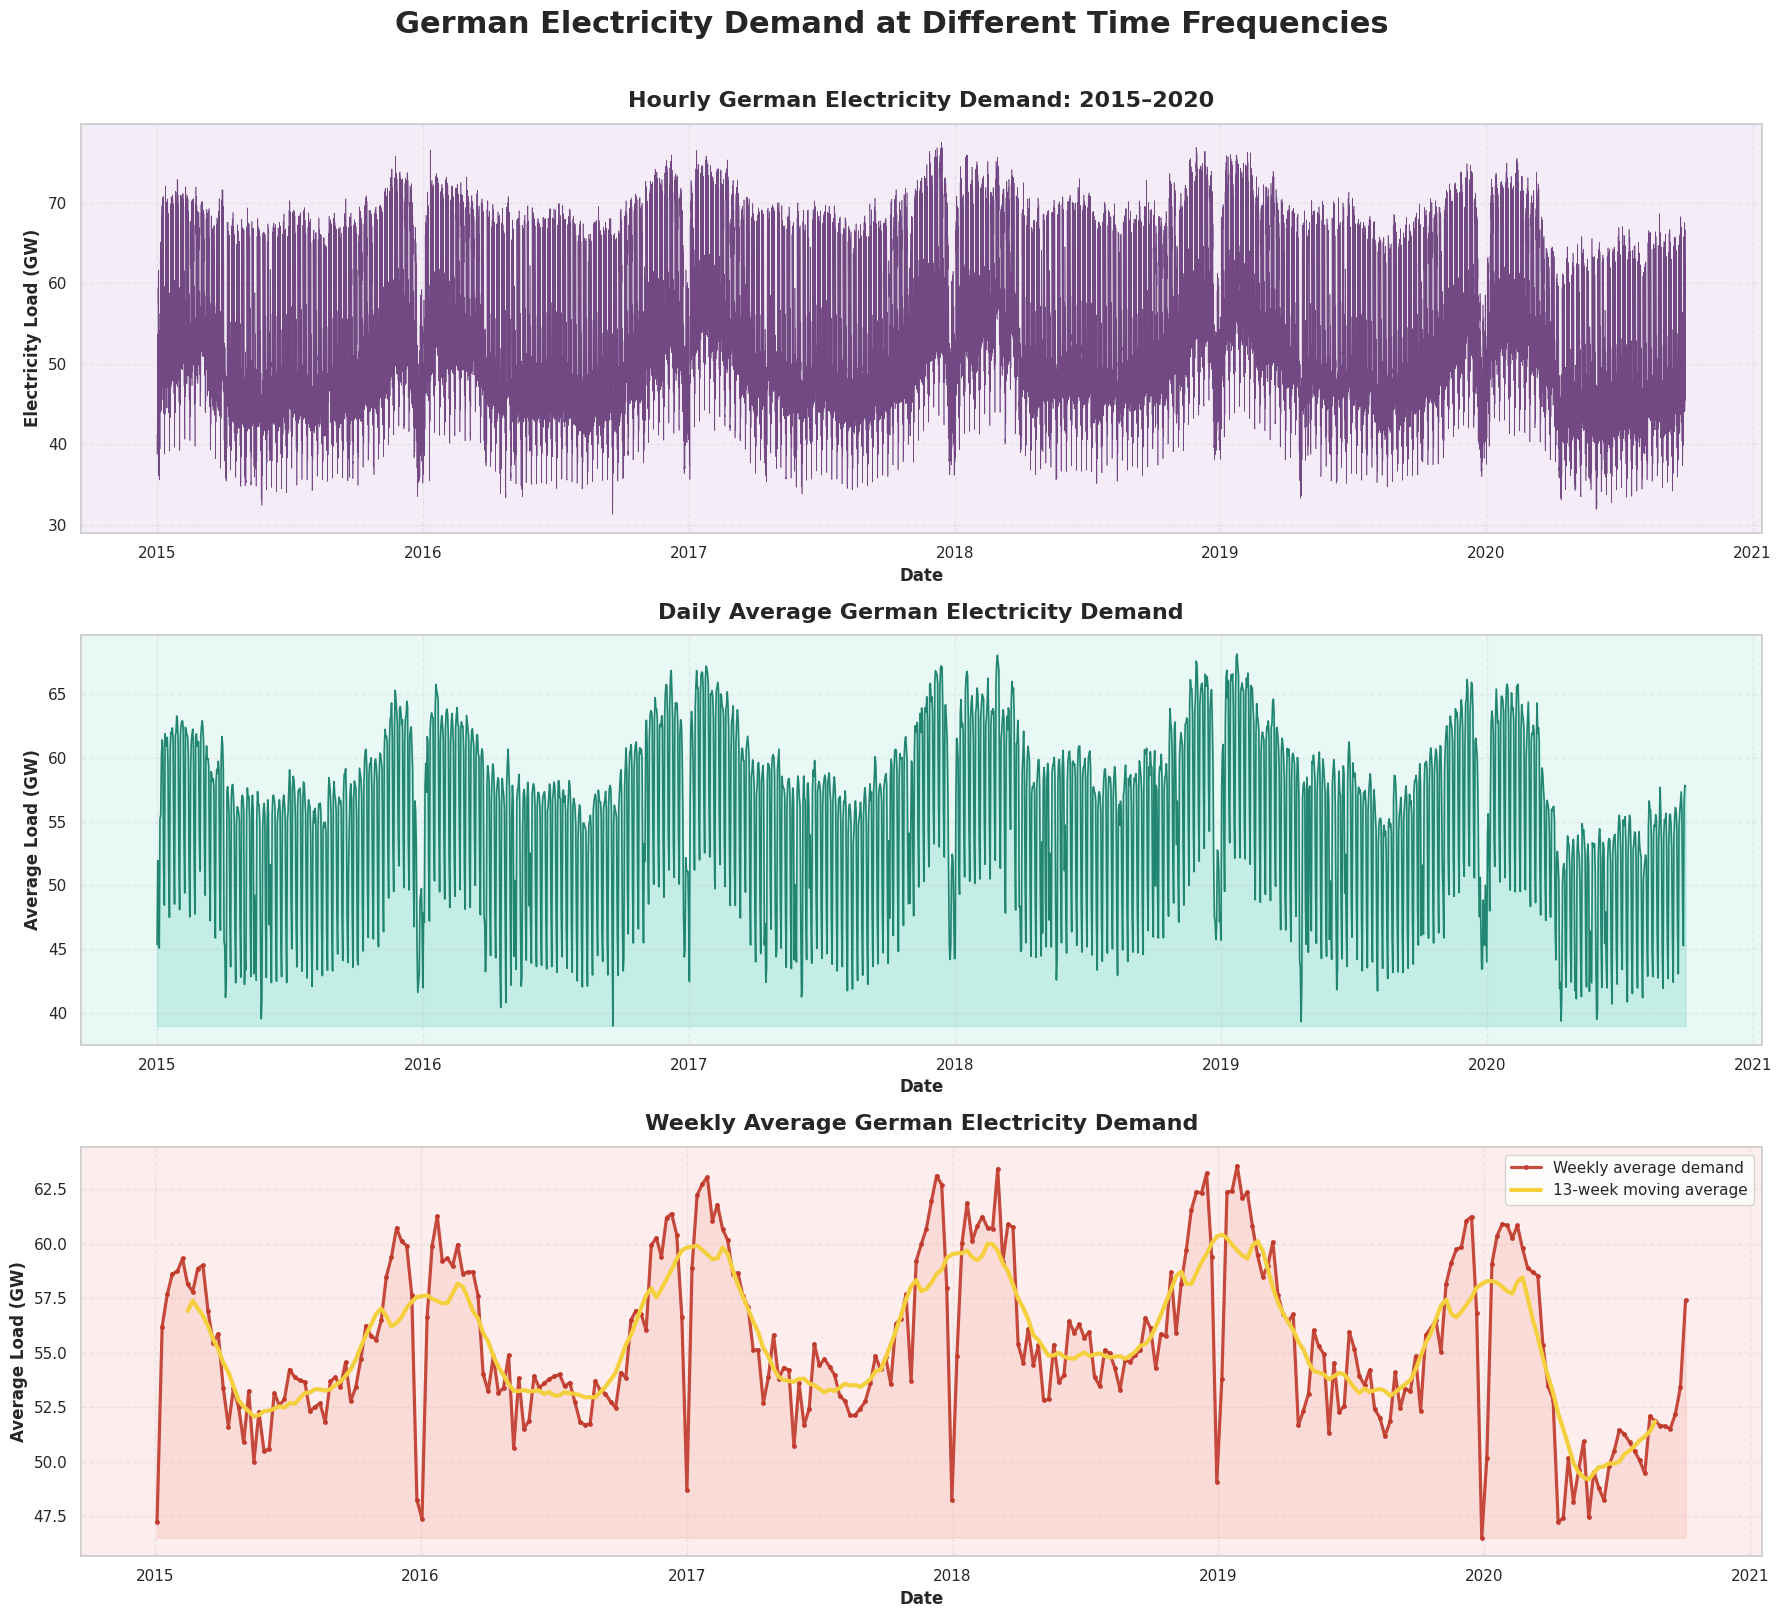

In [ ]:
# ============================================================
# PART 1, Sub-step 1.5:  COLOURFUL INITIAL TIME-SERIES VISUALISATION
# ============================================================

# Create a figure containing three vertically arranged graphs.
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(18, 16)
)

# Add a main heading for the entire figure.
fig.suptitle(
    "German Electricity Demand at Different Time Frequencies",
    fontsize=22,
    fontweight="bold",
    y=1.01
)

# ============================================================
# GRAPH 1: HOURLY ELECTRICITY DEMAND
# ============================================================

# Plot the complete hourly electricity series.
axes[0].plot(
    hourly_load.index,
    hourly_load.values,
    color="#5B2C6F",
    linewidth=0.45,
    alpha=0.85
)

# Add a coloured background.
axes[0].set_facecolor("#F4ECF7")

# Add title and axis labels.
axes[0].set_title(
    "Hourly German Electricity Demand: 2015–2020",
    fontsize=16,
    fontweight="bold",
    pad=12
)

axes[0].set_xlabel(
    "Date",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_ylabel(
    "Electricity Load (GW)",
    fontsize=12,
    fontweight="bold"
)

# Add a grid to make the values easier to read.
axes[0].grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# GRAPH 2: DAILY AVERAGE ELECTRICITY DEMAND
# ============================================================

# Plot the daily average electricity series.
axes[1].plot(
    daily_load.index,
    daily_load.values,
    color="#117A65",
    linewidth=1.2,
    alpha=0.90
)

# Shade the area below the daily electricity curve.
axes[1].fill_between(
    daily_load.index,
    daily_load.values,
    daily_load.min(),
    color="#48C9B0",
    alpha=0.22
)

# Add a coloured background.
axes[1].set_facecolor("#E8F8F5")

# Add title and axis labels.
axes[1].set_title(
    "Daily Average German Electricity Demand",
    fontsize=16,
    fontweight="bold",
    pad=12
)

axes[1].set_xlabel(
    "Date",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Average Load (GW)",
    fontsize=12,
    fontweight="bold"
)

axes[1].grid(
    True,
    linestyle="--",
    alpha=0.35
)

# ============================================================
# GRAPH 3: WEEKLY AVERAGE ELECTRICITY DEMAND
# ============================================================

# Plot the weekly average electricity series.
axes[2].plot(
    weekly_load.index,
    weekly_load.values,
    color="#C0392B",
    linewidth=2.3,
    marker="o",
    markersize=2.5,
    alpha=0.90,
    label="Weekly average demand"
)

# Add a 13-week moving average to make the broad trend clearer.
weekly_moving_average = weekly_load.rolling(
    window=13,
    center=True
).mean()

axes[2].plot(
    weekly_moving_average.index,
    weekly_moving_average.values,
    color="#F4D03F",
    linewidth=3,
    label="13-week moving average"
)

# Shade the area underneath the weekly load.
axes[2].fill_between(
    weekly_load.index,
    weekly_load.values,
    weekly_load.min(),
    color="#F1948A",
    alpha=0.20
)

# Add a coloured background.
axes[2].set_facecolor("#FDEDEC")

# Add title and axis labels.
axes[2].set_title(
    "Weekly Average German Electricity Demand",
    fontsize=16,
    fontweight="bold",
    pad=12
)

axes[2].set_xlabel(
    "Date",
    fontsize=12,
    fontweight="bold"
)

axes[2].set_ylabel(
    "Average Load (GW)",
    fontsize=12,
    fontweight="bold"
)

axes[2].grid(
    True,
    linestyle="--",
    alpha=0.35
)

axes[2].legend(
    fontsize=11,
    loc="best",
    frameon=True
)

# Improve the spacing between the graphs.
plt.tight_layout()

# Display the completed figure.
plt.show()

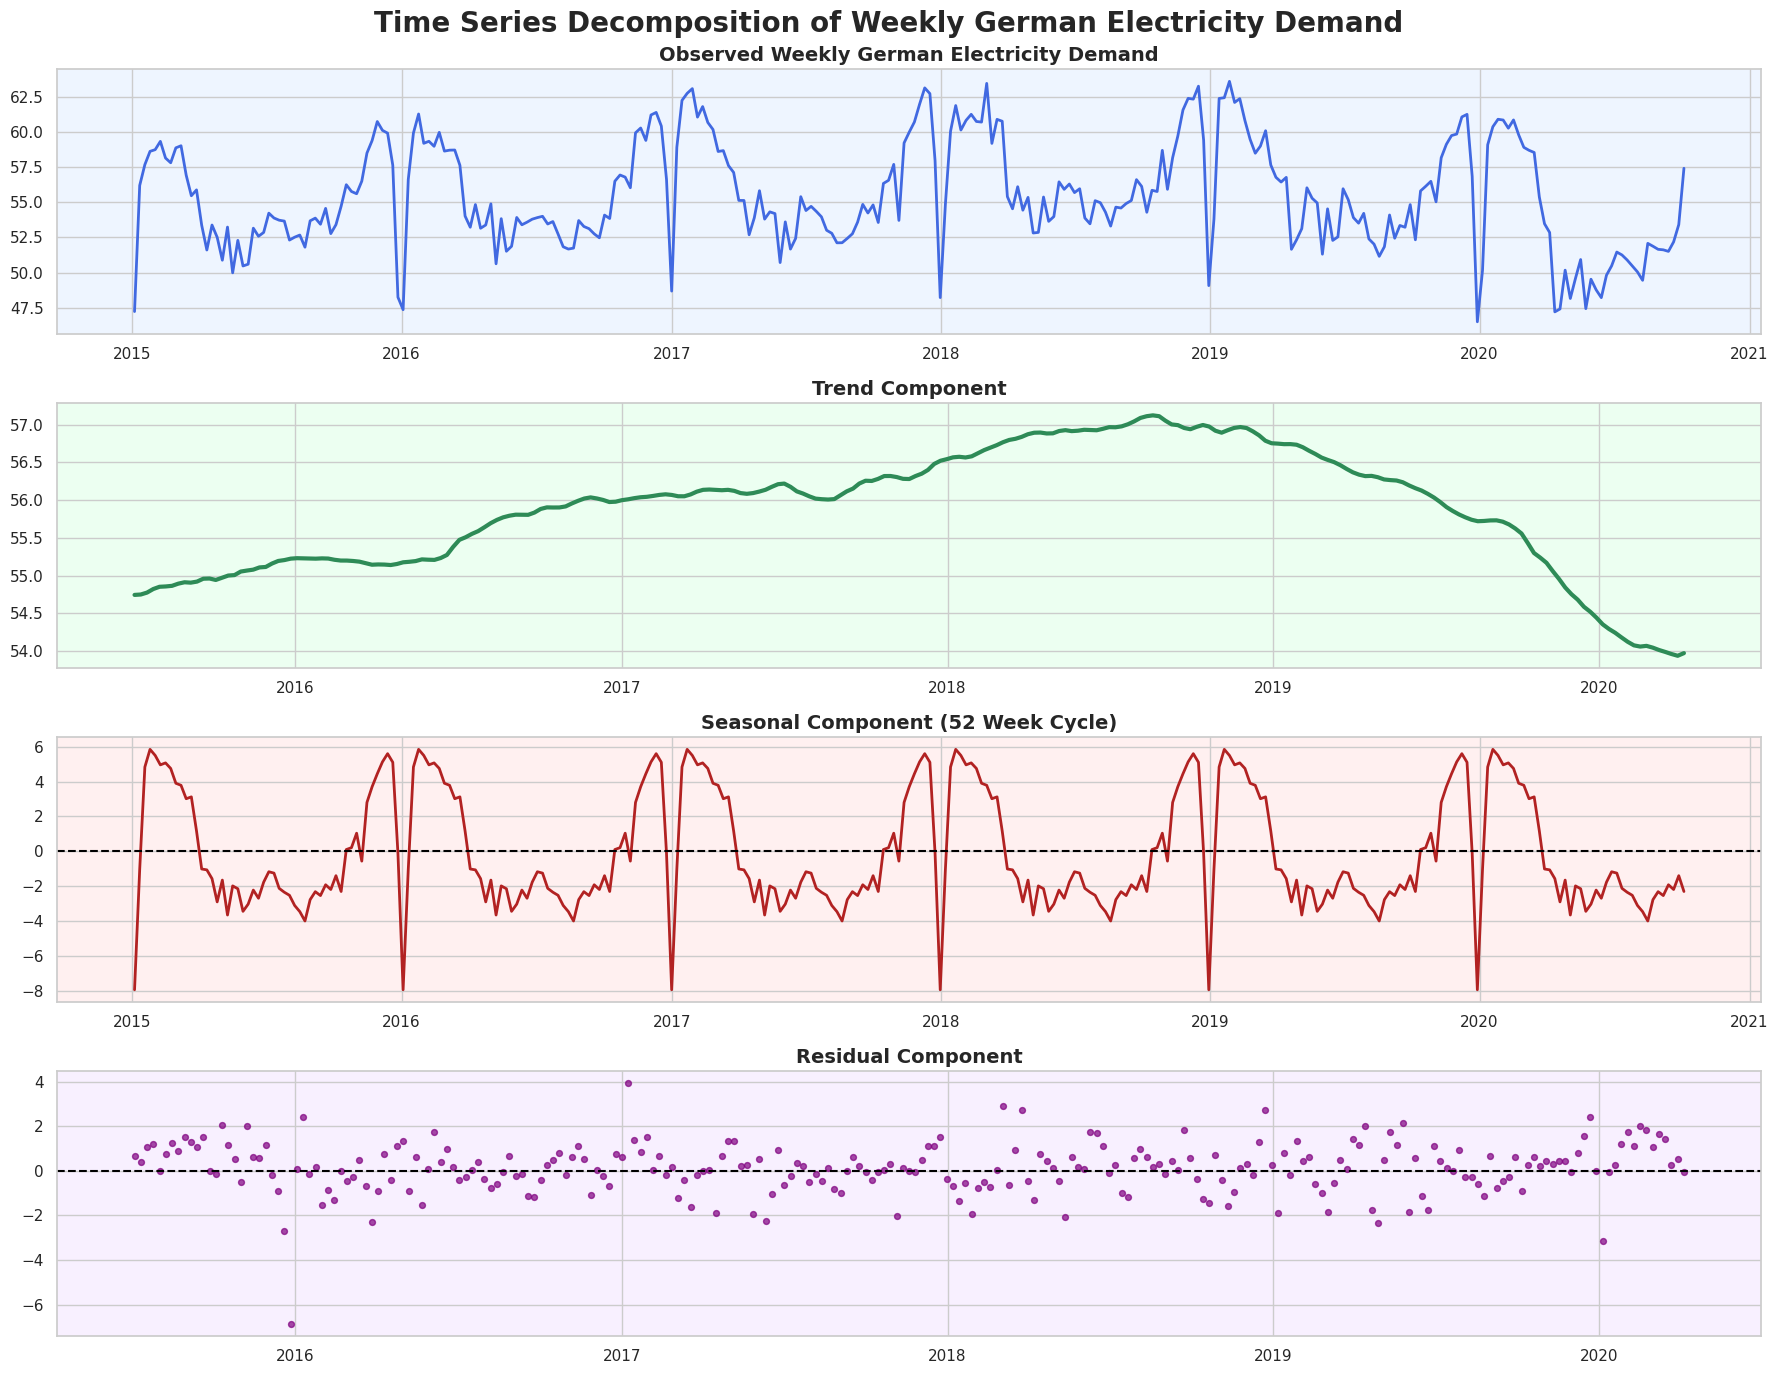

In [ ]:
# ============================================================
# PART 1, Sub-step 1.6:  TIME SERIES DECOMPOSITION
# ============================================================

from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose weekly electricity demand into:
# Trend + Seasonal + Residual components
decomposition = seasonal_decompose(
    weekly_load,
    model="additive",
    period=52
)

# Create colourful decomposition plots
fig, axes = plt.subplots(4, 1, figsize=(18, 14))

# Original series
axes[0].plot(
    decomposition.observed,
    color="royalblue",
    linewidth=2
)
axes[0].set_title(
    "Observed Weekly German Electricity Demand",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_facecolor("#EEF5FF")

# Trend component
axes[1].plot(
    decomposition.trend,
    color="seagreen",
    linewidth=3
)
axes[1].set_title(
    "Trend Component",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_facecolor("#ECFFF1")

# Seasonal component
axes[2].plot(
    decomposition.seasonal,
    color="firebrick",
    linewidth=2
)
axes[2].axhline(
    0,
    color="black",
    linestyle="--"
)
axes[2].set_title(
    "Seasonal Component (52 Week Cycle)",
    fontsize=14,
    fontweight="bold"
)
axes[2].set_facecolor("#FFF0F0")

# Residual component
axes[3].scatter(
    decomposition.resid.index,
    decomposition.resid,
    color="purple",
    s=18,
    alpha=0.7
)
axes[3].axhline(
    0,
    color="black",
    linestyle="--"
)
axes[3].set_title(
    "Residual Component",
    fontsize=14,
    fontweight="bold"
)
axes[3].set_facecolor("#F8F0FF")

plt.suptitle(
    "Time Series Decomposition of Weekly German Electricity Demand",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

STATIONARITY TEST RESULTS


,Test,Statistic,p-value
0,ADF,-4.048,0.001
1,KPSS,0.160,0.100



Interpretation:
✓ ADF indicates the series is stationary.
✓ KPSS indicates the series is stationary.


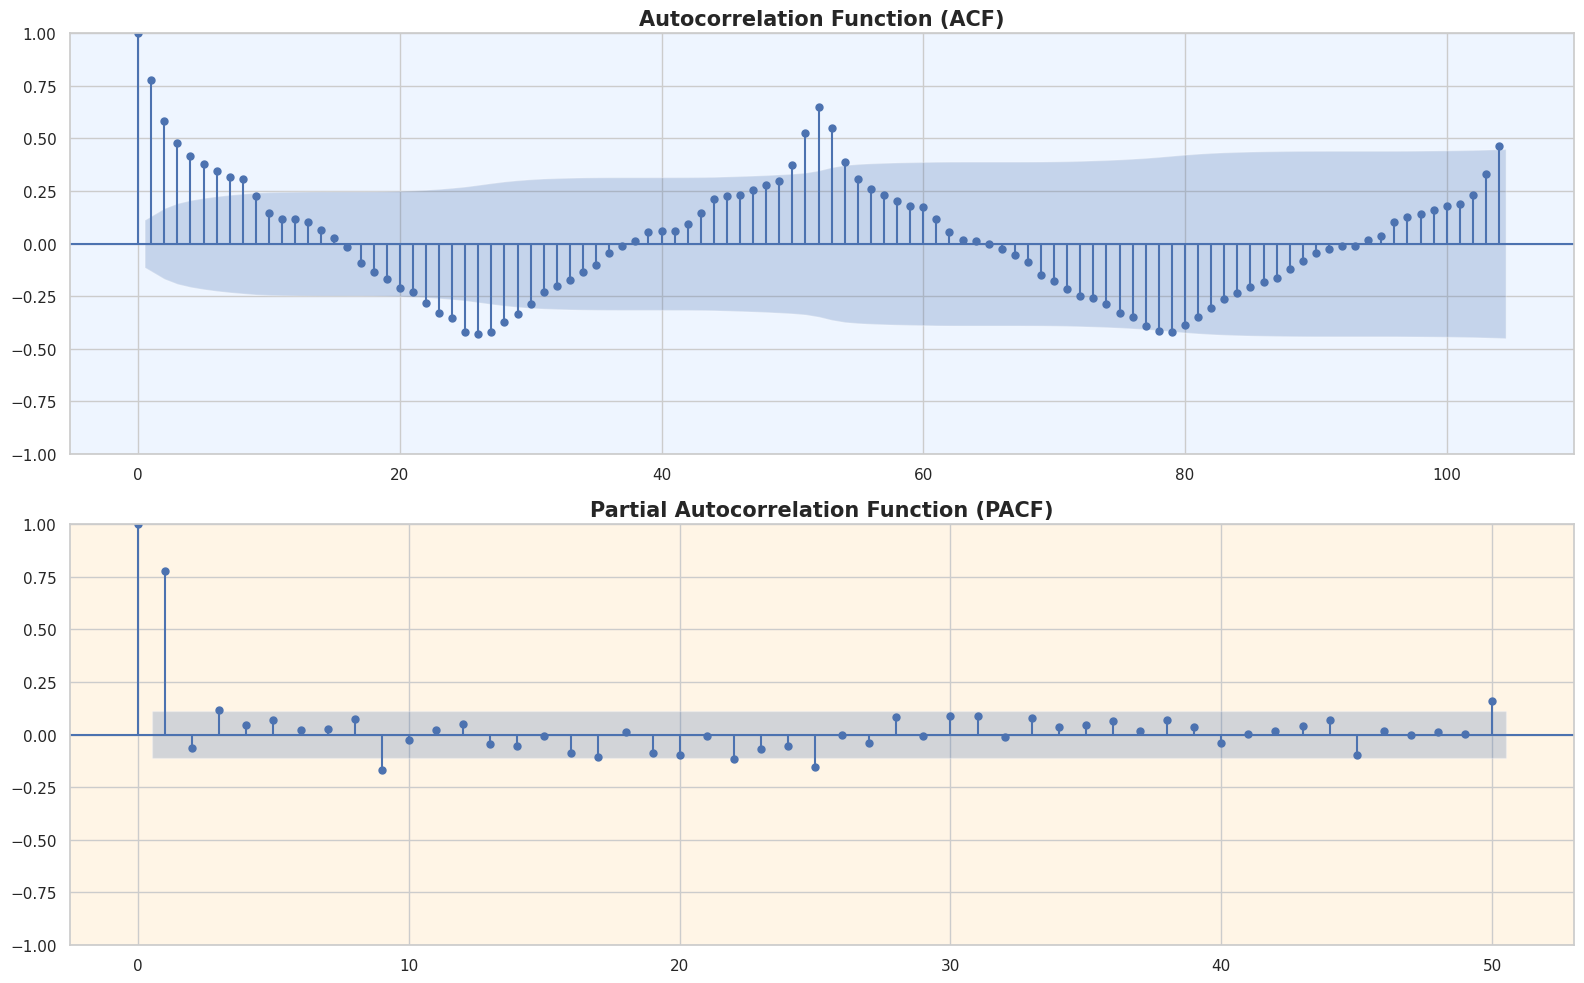

In [ ]:
# ============================================================
# PART 1, Sub-step 1.7:  STATIONARITY TESTS, ACF AND PACF ANALYSIS
# ============================================================

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

# -----------------------------
# Augmented Dickey-Fuller Test
# H0: Series is non-stationary
# -----------------------------
adf_result = adfuller(weekly_load.dropna())

# -----------------------------
# KPSS Test
# H0: Series is stationary
# -----------------------------
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    kpss_result = kpss(
        weekly_load.dropna(),
        regression="c",
        nlags="auto"
    )

# Display results
results_table = pd.DataFrame({
    "Test": ["ADF", "KPSS"],
    "Statistic": [
        adf_result[0],
        kpss_result[0]
    ],
    "p-value": [
        adf_result[1],
        kpss_result[1]
    ]
})

print("=" * 55)
print("STATIONARITY TEST RESULTS")
print("=" * 55)

display(results_table.round(4))

# Interpretation
print("\nInterpretation:")

if adf_result[1] < 0.05:
    print("✓ ADF indicates the series is stationary.")
else:
    print("✗ ADF indicates the series is non-stationary.")

if kpss_result[1] < 0.05:
    print("✗ KPSS indicates the series is non-stationary.")
else:
    print("✓ KPSS indicates the series is stationary.")

# ============================================================
# ACF AND PACF PLOTS
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 10)
)

# -----------------------------
# ACF Plot
# -----------------------------
plot_acf(
    weekly_load.dropna(),
    lags=104,
    ax=axes[0]
)

axes[0].set_title(
    "Autocorrelation Function (ACF)",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_facecolor("#EEF5FF")

# -----------------------------
# PACF Plot
# -----------------------------
plot_pacf(
    weekly_load.dropna(),
    lags=50,
    method="ywm",
    ax=axes[1]
)

axes[1].set_title(
    "Partial Autocorrelation Function (PACF)",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_facecolor("#FFF5E6")

plt.tight_layout()
plt.show()

Training period: 2015-01-04 to 2018-10-07
Testing period:  2018-10-14 to 2020-10-04

Benchmark Forecast Results


,Model,MAE,RMSE,MASE,Bias
0,Seasonal Naive,2.319,3.007,1.732,1.732
1,Mean,3.789,4.397,2.831,0.481
2,Naive,3.783,4.459,2.827,-0.882
3,Drift,4.340,5.118,3.243,1.007


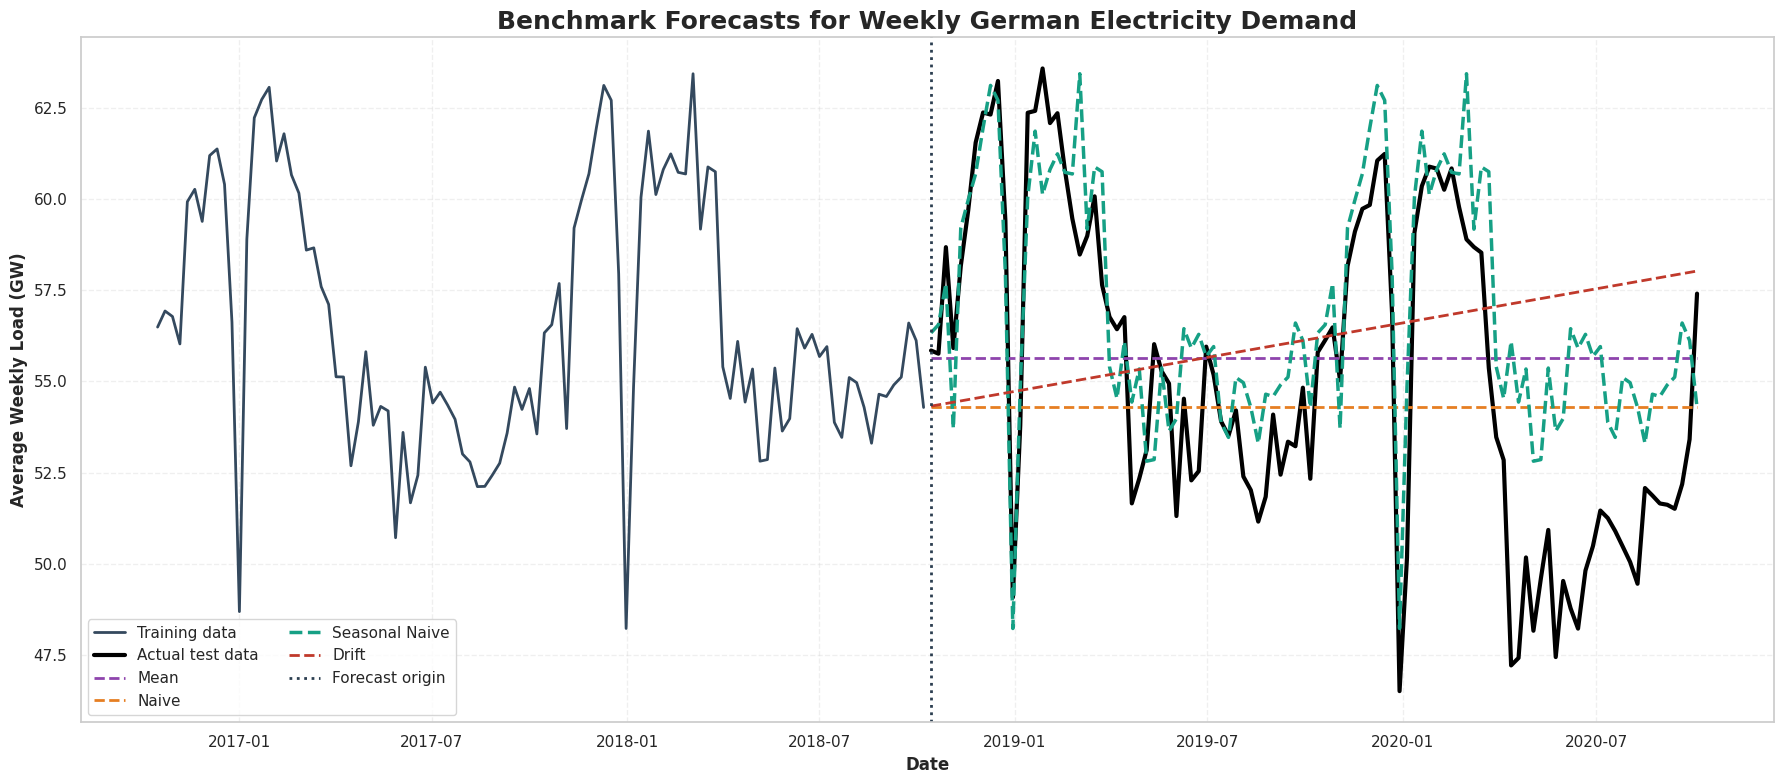

In [ ]:
# ============================================================
# Part 2, Sub-step 2.1: BENCHMARK FORECAST MODELS
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Two-year test period
test_weeks = 104

train = weekly_load.iloc[:-test_weeks].copy()
test = weekly_load.iloc[-test_weeks:].copy()

forecast_horizon = len(test)

print(f"Training period: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing period:  {test.index.min().date()} to {test.index.max().date()}")

# ------------------------------------------------------------
# Evaluation functions
# Part 2, Sub-step 2.2: Mean, Naive, Seasonal Naive and Drift
# ------------------------------------------------------------

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mase(y_true, y_pred, y_train, seasonality=52):
    seasonal_errors = np.abs(
        y_train.iloc[seasonality:].values
        - y_train.iloc[:-seasonality].values
    )

    scale = seasonal_errors.mean()

    return np.mean(
        np.abs(np.asarray(y_true) - np.asarray(y_pred))
    ) / scale


def evaluate_model(name, actual, forecast, training):
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, forecast),
        "RMSE": rmse(actual, forecast),
        "MASE": mase(actual, forecast, training),
        "Bias": np.mean(
            np.asarray(forecast) - np.asarray(actual)
        )
    }


# ------------------------------------------------------------
# 1. Mean forecast
# ------------------------------------------------------------

mean_forecast = pd.Series(
    train.mean(),
    index=test.index
)

# ------------------------------------------------------------
# 2. Naive forecast
# ------------------------------------------------------------

naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)

# ------------------------------------------------------------
# 3. Seasonal Naive forecast
# Uses the final 52 weeks of training data only
# ------------------------------------------------------------

season_length = 52

last_season = train.iloc[-season_length:].values

seasonal_naive_forecast = pd.Series(
    np.tile(last_season, 2)[:forecast_horizon],
    index=test.index
)

# ------------------------------------------------------------
# 4. Drift forecast
# ------------------------------------------------------------

drift_slope = (
    train.iloc[-1] - train.iloc[0]
) / (len(train) - 1)

drift_forecast = pd.Series(
    train.iloc[-1]
    + drift_slope * np.arange(1, forecast_horizon + 1),
    index=test.index
)

# ------------------------------------------------------------
# Part 2, Sub-step 2.3: Benchmark evaluation and forecast plot
# Evaluate all benchmark models
# ------------------------------------------------------------

benchmark_results = []

benchmark_results.append(
    evaluate_model("Mean", test, mean_forecast, train)
)

benchmark_results.append(
    evaluate_model("Naive", test, naive_forecast, train)
)

benchmark_results.append(
    evaluate_model(
        "Seasonal Naive",
        test,
        seasonal_naive_forecast,
        train
    )
)

benchmark_results.append(
    evaluate_model("Drift", test, drift_forecast, train)
)

benchmark_results_df = (
    pd.DataFrame(benchmark_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("\nBenchmark Forecast Results")
display(benchmark_results_df.round(3))

# ------------------------------------------------------------
# Colourful forecast comparison graph
# ------------------------------------------------------------

plt.figure(figsize=(18, 8))

# Show final two years of training data
plt.plot(
    train.iloc[-104:].index,
    train.iloc[-104:],
    color="#34495E",
    linewidth=2,
    label="Training data"
)

plt.plot(
    test.index,
    test,
    color="black",
    linewidth=3,
    label="Actual test data"
)

plt.plot(
    test.index,
    mean_forecast,
    color="#8E44AD",
    linestyle="--",
    linewidth=2,
    label="Mean"
)

plt.plot(
    test.index,
    naive_forecast,
    color="#E67E22",
    linestyle="--",
    linewidth=2,
    label="Naive"
)

plt.plot(
    test.index,
    seasonal_naive_forecast,
    color="#16A085",
    linestyle="--",
    linewidth=2.5,
    label="Seasonal Naive"
)

plt.plot(
    test.index,
    drift_forecast,
    color="#C0392B",
    linestyle="--",
    linewidth=2,
    label="Drift"
)

plt.axvline(
    test.index[0],
    color="#2C3E50",
    linestyle=":",
    linewidth=2,
    label="Forecast origin"
)

plt.title(
    "Benchmark Forecasts for Weekly German Electricity Demand",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Average Weekly Load (GW)", fontsize=12, fontweight="bold")

plt.grid(
    linestyle="--",
    alpha=0.30
)

plt.legend(
    ncol=2,
    fontsize=11
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ASSIGNMENT PART 3
# SUB-STEP 3.1: CREATE 80 SARIMA PARAMETER COMBINATIONS
# ============================================================

import itertools
import random

# Required parameter ranges from assignment
p_values = range(0, 7)
d_values = range(0, 3)
q_values = range(0, 7)

# Seasonal parameters
P_values = range(0, 3)
D_values = range(0, 2)
Q_values = range(0, 3)

# Create all combinations
non_seasonal_orders = list(
    itertools.product(
        p_values,
        d_values,
        q_values
    )
)

seasonal_orders = list(
    itertools.product(
        P_values,
        D_values,
        Q_values
    )
)

all_parameter_sets = list(
    itertools.product(
        non_seasonal_orders,
        seasonal_orders
    )
)

print(f"Total possible combinations: {len(all_parameter_sets):,}")

# Randomly sample 80 combinations
random.seed(42)

parameter_sample = random.sample(
    all_parameter_sets,
    80
)

print(f"Random combinations selected: {len(parameter_sample)}")

Total possible combinations: 2,646
Random combinations selected: 80


In [ ]:
# ============================================================
# ASSIGNMENT PART 3
# SUB-STEP 3.2: STABLE SARIMA AIC SEARCH (80 ITERATIONS)
# ============================================================

import numpy as np
import random
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", ConvergenceWarning)

# Check that training data exists
print(f"Training observations: {len(train)}")

# Create parameter combinations
parameter_sample = []

random.seed(42)

while len(parameter_sample) < 80:

    order = (
        random.randint(0, 6),   # p
        random.randint(0, 2),   # d
        random.randint(0, 6)    # q
    )

    seasonal_order = (
        random.randint(0, 1),   # P
        random.randint(0, 1),   # D
        random.randint(0, 1),   # Q
        52
    )

    parameter_sample.append(
        (order, seasonal_order)
    )

best_aic = np.inf
best_order = None
best_seasonal_order = None
successful_models = 0

for i, (order, seasonal_order) in enumerate(parameter_sample):

    try:

        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(
            disp=False,
            maxiter=30
        )

        successful_models += 1

        if fit.aic < best_aic:
            best_aic = fit.aic
            best_order = order
            best_seasonal_order = seasonal_order

        if (i + 1) % 10 == 0:
            print(f"Completed {i+1}/80 models")

    except:
        continue

print("\nSearch completed successfully.")
print(f"Successful models: {successful_models}")
print(f"Best AIC: {best_aic:.2f}")
print(f"Best order: {best_order}")
print(f"Best seasonal order: {best_seasonal_order}")

Training observations: 197
Completed 10/80 models
Completed 20/80 models
Completed 30/80 models
Completed 40/80 models
Completed 50/80 models
Completed 60/80 models
Completed 70/80 models
Completed 80/80 models

Search completed successfully.
Successful models: 80
Best AIC: 307.67
Best order: (1, 0, 6)
Best seasonal order: (1, 1, 1, 52)


In [ ]:
# ============================================================
# ASSIGNMENT PART 3
# SUB-STEP 3.3: FIT FINAL SARIMA MODEL
# SUB-STEP 3.4: FORECAST LAST TWO YEARS
# SUB-STEP 3.5: EVALUATE MODEL PERFORMANCE
#
# Requirements satisfied:
# ✓ Fit final SARIMA model
# ✓ Forecast final two years
# ✓ Compute RMSE and MAE
# ✓ Generate confidence intervals
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ------------------------------------------------------------
# Fit final SARIMA model using best AIC parameters
# ------------------------------------------------------------

final_sarima = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima.fit(
    disp=False
)

# ------------------------------------------------------------
# Forecast the final two years
# ------------------------------------------------------------

forecast_steps = len(test)

forecast_object = final_sarima_fit.get_forecast(
    steps=forecast_steps
)

sarima_forecast = forecast_object.predicted_mean

sarima_confidence_intervals = forecast_object.conf_int()

# Match test dates
sarima_forecast.index = test.index
sarima_confidence_intervals.index = test.index

# ------------------------------------------------------------
# Calculate evaluation metrics
# ------------------------------------------------------------

sarima_mae = mean_absolute_error(
    test,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

# MASE calculation
seasonality = 52

naive_errors = np.abs(
    train.iloc[seasonality:].values
    - train.iloc[:-seasonality].values
)

mase_scale = naive_errors.mean()

sarima_mase = np.mean(
    np.abs(
        test.values - sarima_forecast.values
    )
) / mase_scale

# Forecast bias
sarima_bias = np.mean(
    sarima_forecast.values - test.values
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 60)
print("FINAL SARIMA MODEL RESULTS")
print("=" * 60)

print(f"Best Order:            {best_order}")
print(f"Best Seasonal Order:   {best_seasonal_order}")

print("\nForecast Performance")
print(f"MAE  : {sarima_mae:.3f}")
print(f"RMSE : {sarima_rmse:.3f}")
print(f"MASE : {sarima_mase:.3f}")
print(f"Bias : {sarima_bias:.3f}")

FINAL SARIMA MODEL RESULTS
Best Order:            (1, 0, 6)
Best Seasonal Order:   (1, 1, 1, 52)

Forecast Performance
MAE  : 3.030
RMSE : 3.736
MASE : 2.264
Bias : 2.806


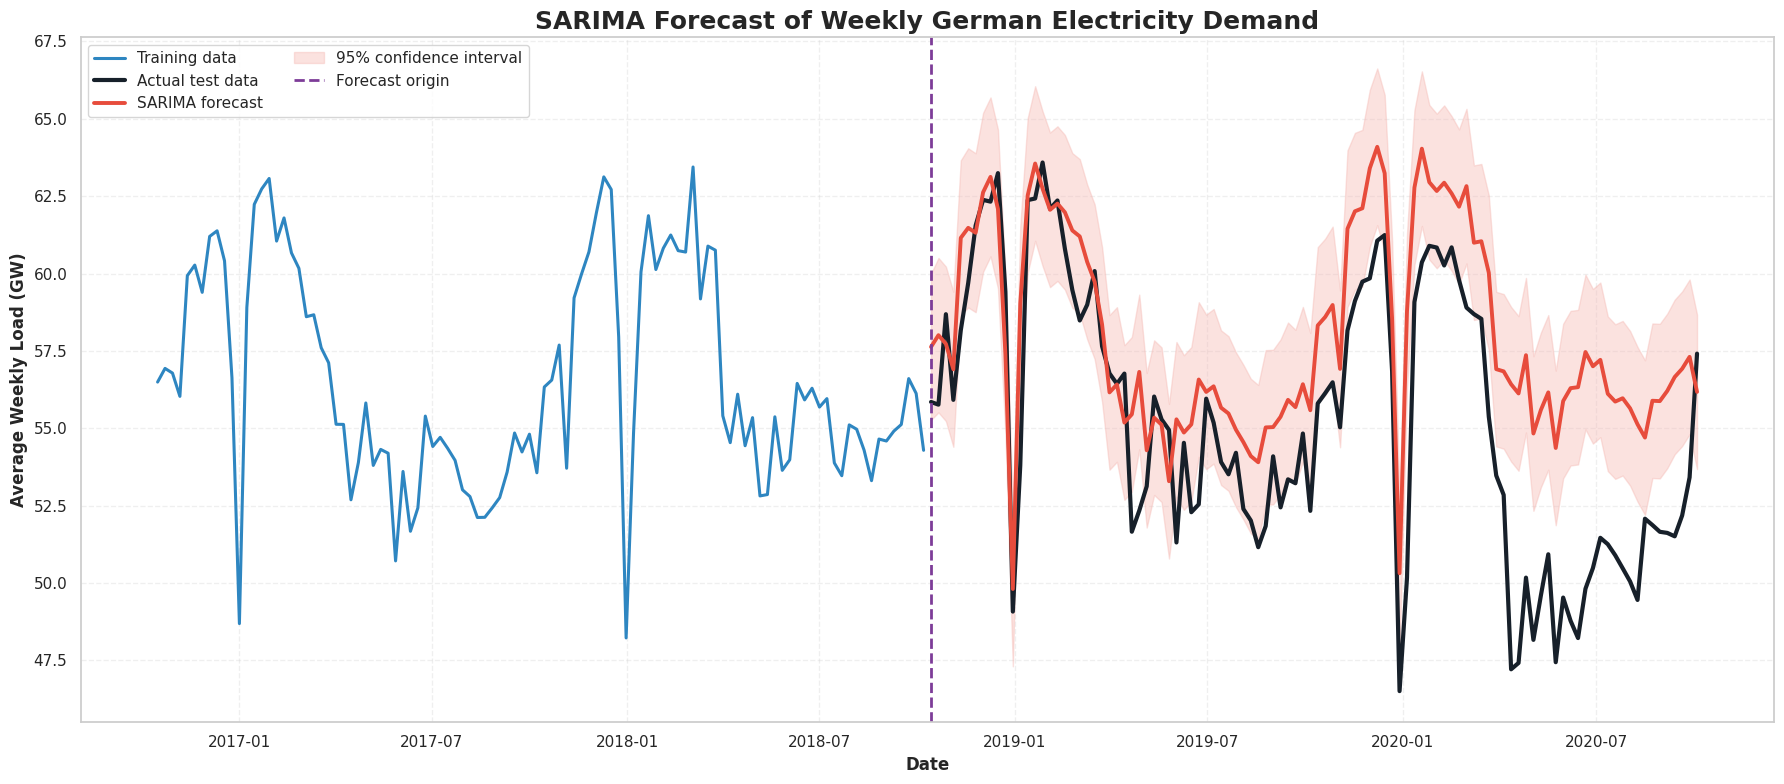

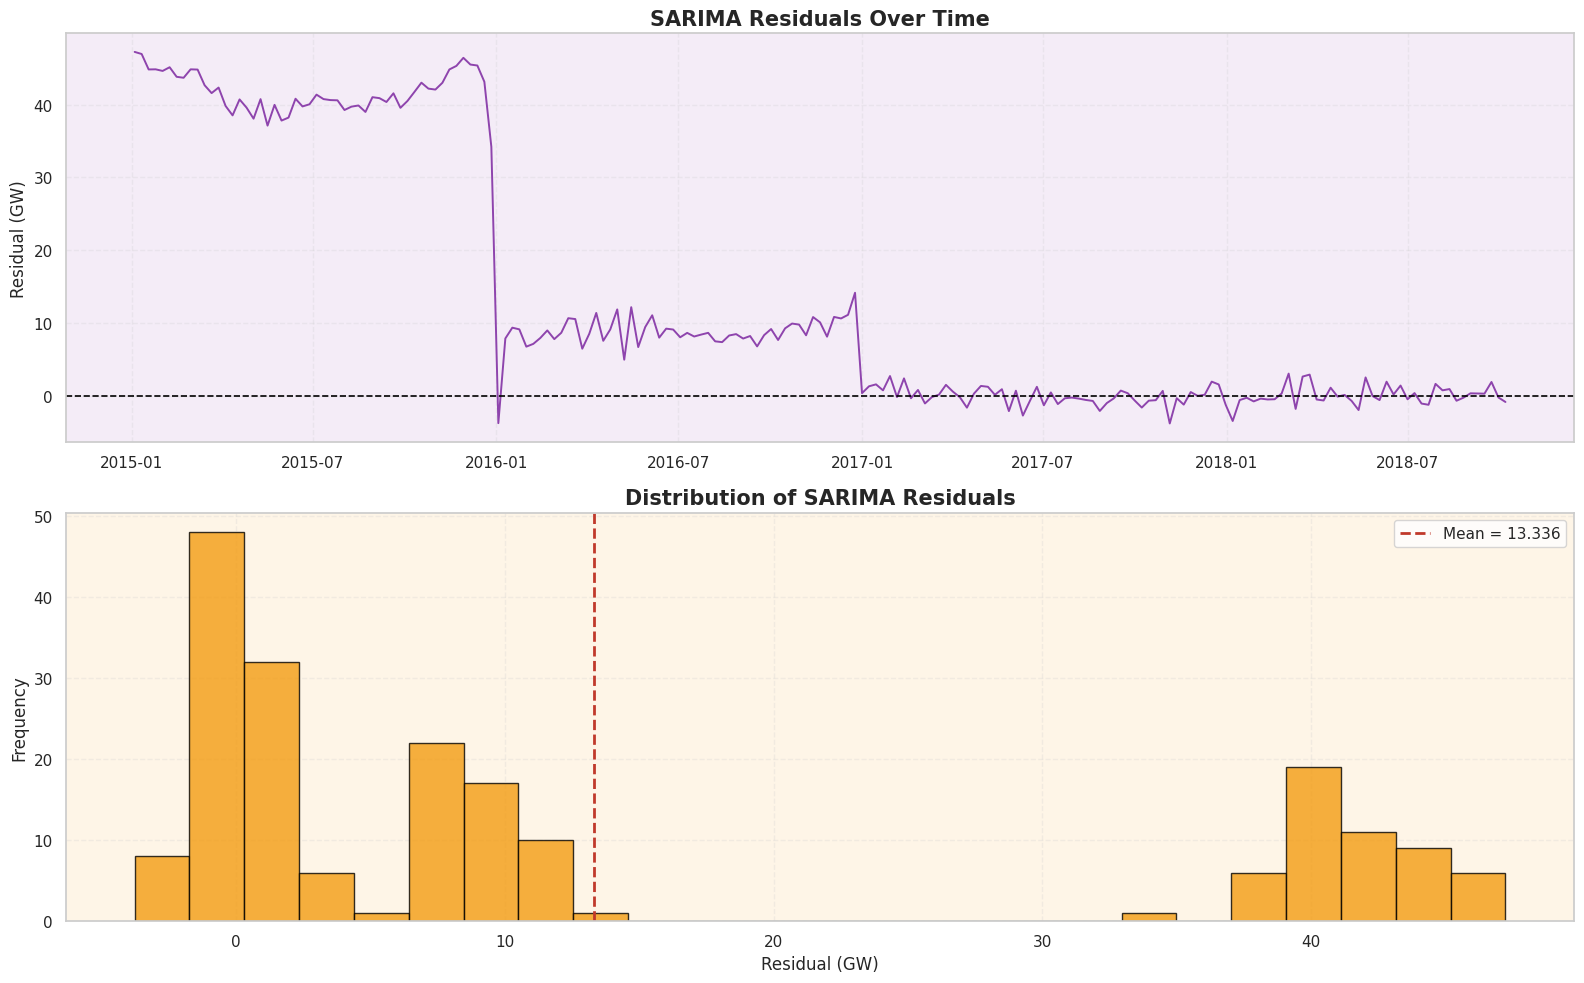

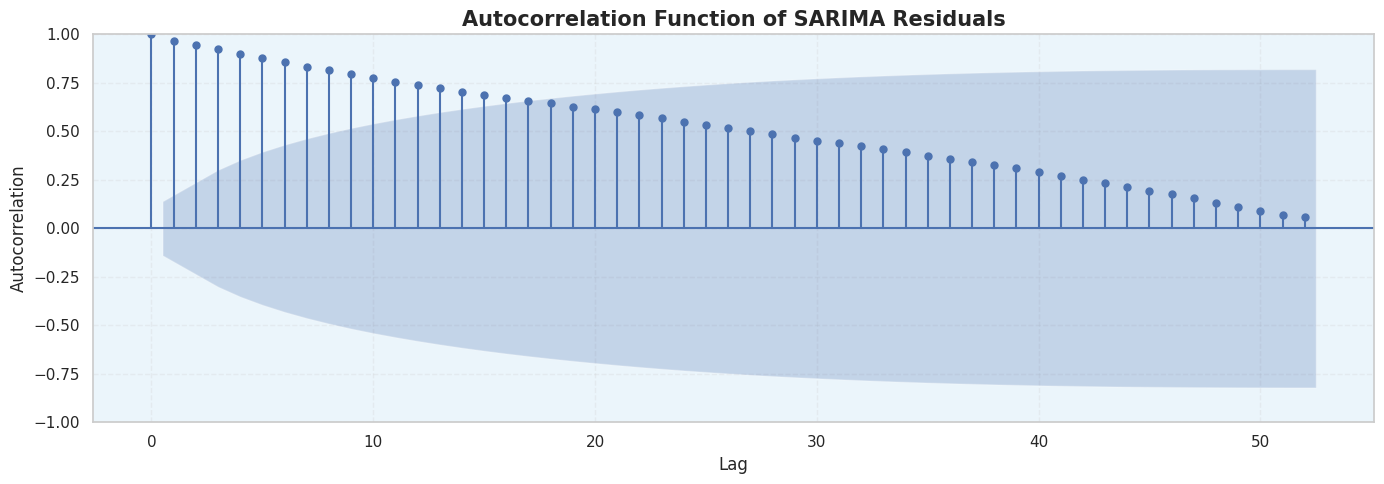

In [ ]:
# ============================================================
# ASSIGNMENT PART 3
# SUB-STEP 3.6: PLOT SARIMA FORECAST WITH CONFIDENCE INTERVAL
# SUB-STEP 3.7: CHECK SARIMA RESIDUALS
#
# Requirements satisfied:
# ✓ Plot the final two-year forecast
# ✓ Add confidence intervals
# ✓ Inspect residuals
# ✓ Inspect residual distribution
# ✓ Create ACF plot of residuals
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf

# ------------------------------------------------------------
# 1. SARIMA FORECAST PLOT
# ------------------------------------------------------------

plt.figure(figsize=(18, 8))

# Show the final two years of training data for context.
plt.plot(
    train.iloc[-104:].index,
    train.iloc[-104:].values,
    color="#2E86C1",
    linewidth=2.2,
    label="Training data"
)

# Plot actual test data.
plt.plot(
    test.index,
    test.values,
    color="#17202A",
    linewidth=3,
    label="Actual test data"
)

# Plot SARIMA forecast.
plt.plot(
    sarima_forecast.index,
    sarima_forecast.values,
    color="#E74C3C",
    linewidth=2.8,
    label="SARIMA forecast"
)

# Add 95% confidence interval.
plt.fill_between(
    test.index,
    sarima_confidence_intervals.iloc[:, 0],
    sarima_confidence_intervals.iloc[:, 1],
    color="#F5B7B1",
    alpha=0.40,
    label="95% confidence interval"
)

# Mark the start of the forecast period.
plt.axvline(
    test.index[0],
    color="#7D3C98",
    linestyle="--",
    linewidth=2,
    label="Forecast origin"
)

plt.title(
    "SARIMA Forecast of Weekly German Electricity Demand",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Weekly Load (GW)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    linestyle="--",
    alpha=0.30
)

plt.legend(
    fontsize=11,
    ncol=2
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. RESIDUAL DIAGNOSTICS
# ------------------------------------------------------------

# Extract residuals from the fitted SARIMA model.
sarima_residuals = final_sarima_fit.resid.dropna()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 10)
)

# Residual time-series plot.
axes[0].plot(
    sarima_residuals.index,
    sarima_residuals.values,
    color="#8E44AD",
    linewidth=1.4
)

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2
)

axes[0].set_title(
    "SARIMA Residuals Over Time",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_ylabel("Residual (GW)")
axes[0].set_facecolor("#F4ECF7")
axes[0].grid(linestyle="--", alpha=0.25)

# Residual distribution.
axes[1].hist(
    sarima_residuals,
    bins=25,
    color="#F39C12",
    edgecolor="black",
    alpha=0.80
)

axes[1].axvline(
    sarima_residuals.mean(),
    color="#C0392B",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {sarima_residuals.mean():.3f}"
)

axes[1].set_title(
    "Distribution of SARIMA Residuals",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Residual (GW)")
axes[1].set_ylabel("Frequency")
axes[1].set_facecolor("#FEF5E7")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. RESIDUAL ACF PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    sarima_residuals,
    lags=min(52, len(sarima_residuals) // 2 - 1),
    ax=ax
)

ax.set_title(
    "Autocorrelation Function of SARIMA Residuals",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.set_facecolor("#EBF5FB")
ax.grid(linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ASSIGNMENT PART 4
# SUB-STEP 4.1: DOWNLOAD BERLIN TEMPERATURE DATA
#
# Requirement:
# Use Berlin as a representative location for Germany.
# ============================================================

import requests
import pandas as pd

# Open-Meteo archive API endpoint
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 52.52,          # Berlin latitude
    "longitude": 13.41,         # Berlin longitude
    "start_date": "2015-01-01",
    "end_date": "2020-10-04",
    "daily": "temperature_2m_mean",
    "timezone": "Europe/Berlin"
}

response = requests.get(url, params=params)
data = response.json()

# Create temperature dataframe
temp_daily = pd.DataFrame({
    "date": pd.to_datetime(data["daily"]["time"]),
    "temperature_mean": data["daily"]["temperature_2m_mean"]
})

temp_daily = temp_daily.set_index("date")

print("Temperature data downloaded successfully.")
print(f"Number of daily observations: {len(temp_daily)}")

temp_daily.head()

Temperature data downloaded successfully.
Number of daily observations: 2104


,temperature_mean
date,
2015-01-01,2.800
2015-01-02,4.600
2015-01-03,3.900
2015-01-04,3.000
2015-01-05,2.700


In [ ]:
# ============================================================
# ASSIGNMENT PART 4
# SUB-STEP 4.2: CREATE WEEKLY TEMPERATURE FEATURES
#
# Requirement:
# Convert daily temperature to weekly explanatory variables.
# ============================================================

# Weekly temperature dataframe
temp_weekly = pd.DataFrame(index=weekly_load.index)

# Weekly mean temperature
temp_weekly["temp_mean"] = (
    temp_daily["temperature_mean"]
    .resample("W-SUN")
    .mean()
)

# Weekly minimum temperature
temp_weekly["temp_min"] = (
    temp_daily["temperature_mean"]
    .resample("W-SUN")
    .min()
)

# Weekly maximum temperature
temp_weekly["temp_max"] = (
    temp_daily["temperature_mean"]
    .resample("W-SUN")
    .max()
)

# Heating degree days
base_heating = 15.5

temp_weekly["heating_degree_days"] = (
    np.maximum(
        base_heating - temp_daily["temperature_mean"],
        0
    )
    .resample("W-SUN")
    .sum()
)

# Cooling degree days
base_cooling = 22

temp_weekly["cooling_degree_days"] = (
    np.maximum(
        temp_daily["temperature_mean"] - base_cooling,
        0
    )
    .resample("W-SUN")
    .sum()
)

# Fill any missing values
temp_weekly = temp_weekly.interpolate()

print("Weekly temperature features created successfully.")

display(
    temp_weekly.head()
)

Weekly temperature features created successfully.


,temp_mean,temp_min,temp_max,heating_degree_days,cooling_degree_days
date,,,,,
2015-01-04,3.575,2.800,4.600,47.700,0.000
2015-01-11,3.886,1.200,8.500,81.300,0.000
2015-01-18,4.900,-0.800,9.200,74.200,0.000
2015-01-25,0.029,-0.700,0.900,108.300,0.000
2015-02-01,1.414,-0.100,2.800,98.600,0.000


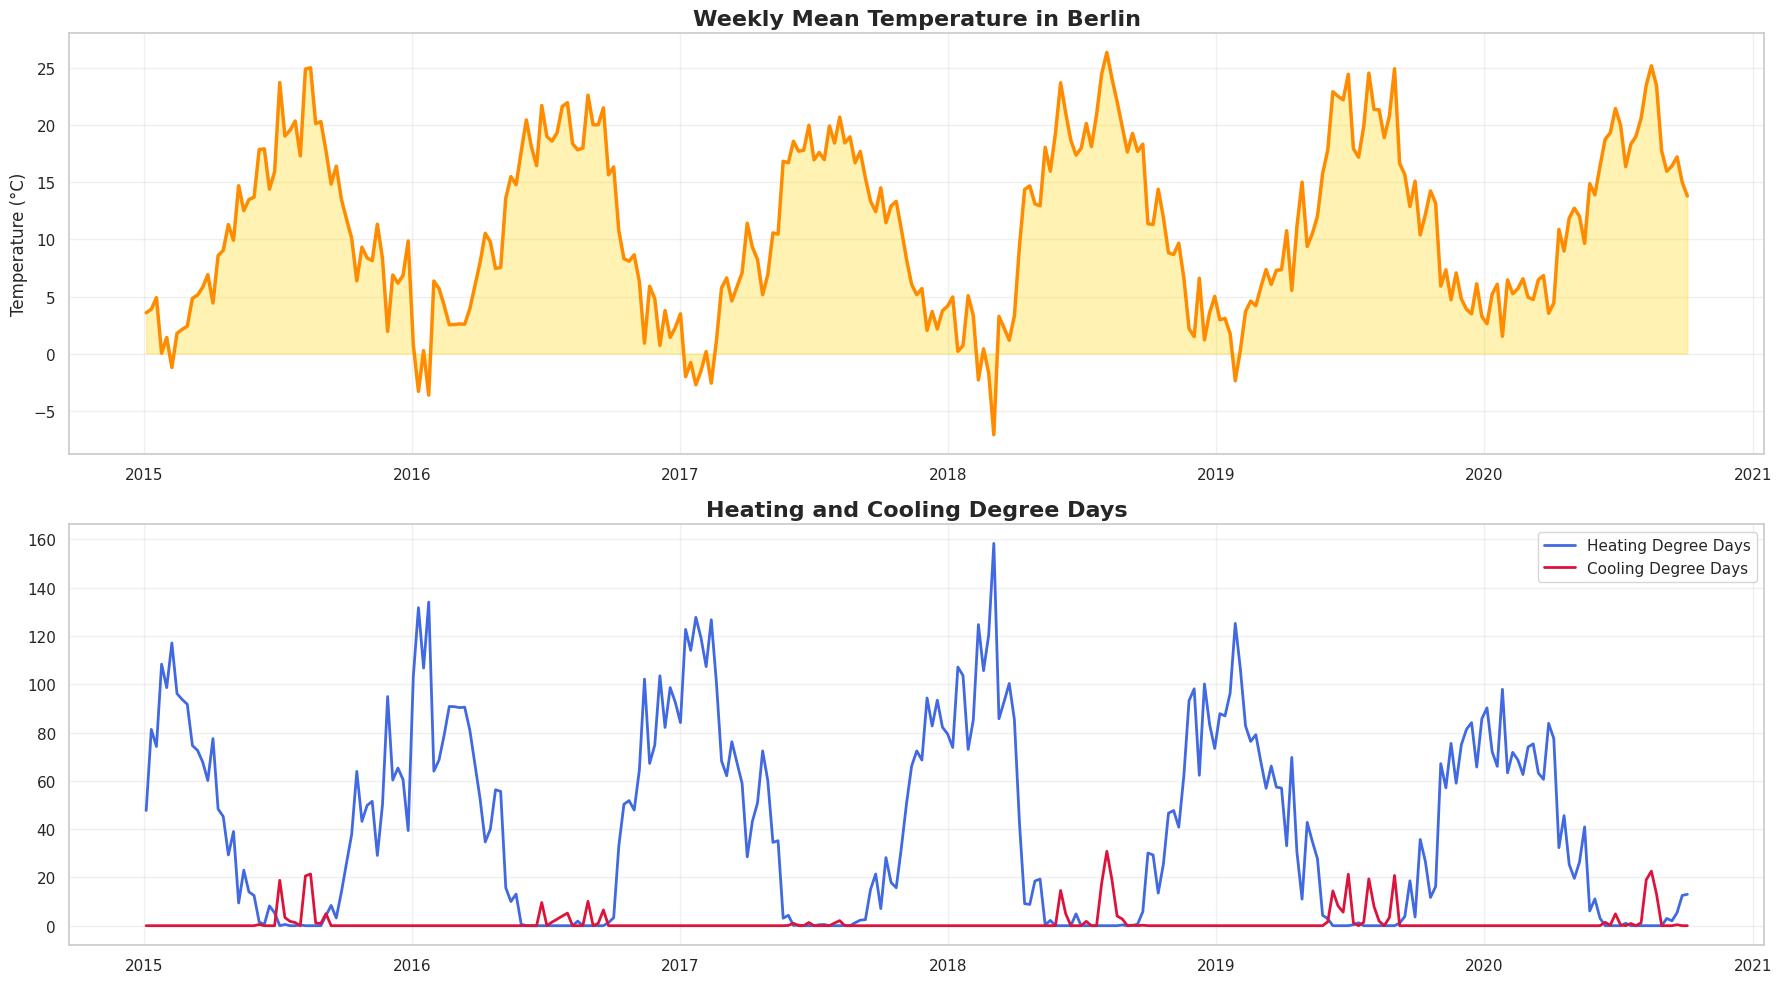

In [ ]:
# ============================================================
# ASSIGNMENT PART 4
# SUB-STEP 4.3: TEMPERATURE VISUALISATION
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(18, 10)
)

# Weekly mean temperature
axes[0].plot(
    temp_weekly.index,
    temp_weekly["temp_mean"],
    color="darkorange",
    linewidth=2.5
)

axes[0].fill_between(
    temp_weekly.index,
    temp_weekly["temp_mean"],
    color="gold",
    alpha=0.3
)

axes[0].set_title(
    "Weekly Mean Temperature in Berlin",
    fontsize=16,
    fontweight="bold"
)

axes[0].set_ylabel("Temperature (°C)")
axes[0].grid(alpha=0.3)

# Heating and cooling degree days
axes[1].plot(
    temp_weekly.index,
    temp_weekly["heating_degree_days"],
    color="royalblue",
    linewidth=2,
    label="Heating Degree Days"
)

axes[1].plot(
    temp_weekly.index,
    temp_weekly["cooling_degree_days"],
    color="crimson",
    linewidth=2,
    label="Cooling Degree Days"
)

axes[1].set_title(
    "Heating and Cooling Degree Days",
    fontsize=16,
    fontweight="bold"
)

axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ASSIGNMENT PART 4
# SUB-STEP 4.4: PREPARE EXOGENOUS VARIABLES
# SUB-STEP 4.5: FIT SARIMAX MODEL
#
# Requirement:
# Add temperature variables to create the X in SARIMAX.
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Select temperature features
exogenous_features = temp_weekly[
    [
        "temp_mean",
        "heating_degree_days",
        "cooling_degree_days"
    ]
].copy()

# Align dates with electricity demand
exogenous_features = exogenous_features.reindex(
    weekly_load.index
)

# Fill any small gaps
exogenous_features = exogenous_features.interpolate(
    method="time"
)

# Train and test exogenous variables
X_train_exog = exogenous_features.loc[train.index]
X_test_exog = exogenous_features.loc[test.index]

print("Training exogenous shape:", X_train_exog.shape)
print("Testing exogenous shape :", X_test_exog.shape)

# Fit SARIMAX model
sarimax_model = SARIMAX(
    train,
    exog=X_train_exog,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(
    disp=False
)

print("\nSARIMAX model fitted successfully.")
print(f"SARIMAX AIC: {sarimax_fit.aic:.2f}")

Training exogenous shape: (197, 3)
Testing exogenous shape : (104, 3)

SARIMAX model fitted successfully.
SARIMAX AIC: 293.43


In [ ]:
# ============================================================
# ASSIGNMENT PART 4
# SUB-STEP 4.6: FORECAST WITH SARIMAX
# SUB-STEP 4.7A: EVALUATE SARIMAX PERFORMANCE
#
# Requirement:
# Produce explanatory forecast using temperature.
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Forecast
sarimax_forecast_object = sarimax_fit.get_forecast(
    steps=len(test),
    exog=X_test_exog
)

sarimax_forecast = sarimax_forecast_object.predicted_mean

sarimax_confidence = (
    sarimax_forecast_object.conf_int()
)

# Match dates
sarimax_forecast.index = test.index
sarimax_confidence.index = test.index

# Evaluation metrics
sarimax_mae = mean_absolute_error(
    test,
    sarimax_forecast
)

sarimax_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarimax_forecast
    )
)

print("=" * 55)
print("SARIMAX RESULTS")
print("=" * 55)

print(f"MAE  : {sarimax_mae:.3f}")
print(f"RMSE : {sarimax_rmse:.3f}")

print("\nComparison with previous models")
print(f"Seasonal Naive RMSE : 3.007")
print(f"SARIMA RMSE         : {sarima_rmse:.3f}")
print(f"SARIMAX RMSE        : {sarimax_rmse:.3f}")

# Simple interpretation
if sarimax_rmse < sarima_rmse:
    print("\n✓ Temperature improved forecasting accuracy.")
else:
    print("\n✗ Temperature did not improve forecasting accuracy.")

print(
    "\nNote: This is a conditional forecast because "
    "future observed temperatures were supplied to the model."
)

SARIMAX RESULTS
MAE  : 2.819
RMSE : 3.580

Comparison with previous models
Seasonal Naive RMSE : 3.007
SARIMA RMSE         : 3.736
SARIMAX RMSE        : 3.580

✓ Temperature improved forecasting accuracy.

Note: This is a conditional forecast because future observed temperatures were supplied to the model.


In [ ]:
# ============================================================
# ASSIGNMENT PART 4
# SUB-STEP 4.7B: CALCULATE SARIMAX MASE AND BIAS
# ============================================================

# Seasonal naive denominator
seasonality = 52

seasonal_training_errors = np.abs(
    train.iloc[seasonality:].values -
    train.iloc[:-seasonality].values
)

mase_scale = seasonal_training_errors.mean()

# SARIMAX MASE
sarimax_mase = np.mean(
    np.abs(
        test.values -
        sarimax_forecast.values
    )
) / mase_scale

# SARIMAX Bias
sarimax_bias = np.mean(
    sarimax_forecast.values -
    test.values
)

print("SARIMAX MASE :", round(sarimax_mase, 3))
print("SARIMAX Bias :", round(sarimax_bias, 3))

SARIMAX MASE : 2.106
SARIMAX Bias : 2.594


In [ ]:
# ============================================================
# ASSIGNMENT PART 5
# SUB-STEP 5.1: FAST FEATURE DATASET CREATION
# ============================================================

import numpy as np
import pandas as pd
import time

start_time = time.time()

# Create target dataframe
feature_df = weekly_load.to_frame(name="load_gw").copy()

# Lag features
lags = [1, 2, 4, 8, 13, 26, 52]

for lag in lags:
    feature_df[f"lag_{lag}"] = feature_df["load_gw"].shift(lag)

# Rolling features using only previous values
shifted_load = feature_df["load_gw"].shift(1)

feature_df["rolling_mean_4"] = shifted_load.rolling(4).mean()
feature_df["rolling_mean_13"] = shifted_load.rolling(13).mean()
feature_df["rolling_mean_52"] = shifted_load.rolling(52).mean()

# Calendar features
week_number = feature_df.index.isocalendar().week.astype(int)

feature_df["week_of_year"] = week_number.values
feature_df["year"] = feature_df.index.year

# Fourier seasonal features
for k in range(1, 4):
    feature_df[f"sin_{k}"] = np.sin(
        2 * np.pi * k * feature_df["week_of_year"] / 52
    )

    feature_df[f"cos_{k}"] = np.cos(
        2 * np.pi * k * feature_df["week_of_year"] / 52
    )

# Add weekly temperature variables directly
feature_df["temp_mean"] = temp_weekly["temp_mean"].reindex(feature_df.index)
feature_df["heating_degree_days"] = (
    temp_weekly["heating_degree_days"].reindex(feature_df.index)
)
feature_df["cooling_degree_days"] = (
    temp_weekly["cooling_degree_days"].reindex(feature_df.index)
)

# Fill small temperature gaps
temperature_columns = [
    "temp_mean",
    "heating_degree_days",
    "cooling_degree_days"
]

feature_df[temperature_columns] = (
    feature_df[temperature_columns]
    .interpolate(method="time", limit_direction="both")
)

# Remove initial missing rows caused by lag 52
feature_df = feature_df.dropna()

elapsed_time = time.time() - start_time

print("Feature dataset created successfully.")
print("Dataset shape:", feature_df.shape)
print("Missing values:", feature_df.isna().sum().sum())
print(f"Execution time: {elapsed_time:.2f} seconds")

display(feature_df.head())

Feature dataset created successfully.
Dataset shape: (249, 22)
Missing values: 0
Execution time: 0.01 seconds


,load_gw,lag_1,lag_2,lag_4,lag_8,lag_13,lag_26,lag_52,rolling_mean_4,rolling_mean_13,rolling_mean_52,week_of_year,year,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3,temp_mean,heating_degree_days,cooling_degree_days
date,,,,,,,,,,,,,,,,,,,,,,
2016-01-03,47.364,48.253,57.628,60.107,56.496,53.405,54.223,47.234,56.474,56.671,54.742,53,2016,0.121,0.993,0.239,0.971,0.355,0.935,0.757,103.200,0.000
2016-01-10,56.615,47.364,48.253,59.907,58.491,54.715,53.878,56.191,53.288,56.207,54.744,1,2016,0.121,0.993,0.239,0.971,0.355,0.935,-3.314,131.700,0.000
2016-01-17,59.914,56.615,47.364,57.628,59.382,56.244,53.723,57.673,52.465,56.353,54.753,2,2016,0.239,0.971,0.465,0.885,0.663,0.749,0.257,106.700,0.000
2016-01-24,61.268,59.914,56.615,48.253,60.733,55.764,53.660,58.613,53.037,56.635,54.796,3,2016,0.355,0.935,0.663,0.749,0.885,0.465,-3.643,134.000,0.000
2016-01-31,59.185,61.268,59.914,47.364,60.107,55.602,52.311,58.734,56.290,57.058,54.847,4,2016,0.465,0.885,0.823,0.568,0.993,0.121,6.357,64.000,0.000


In [ ]:
# ============================================================
# ASSIGNMENT PART 5
# SUB-STEP 5.2: PREPARE LEAKAGE-FREE TRAINING DATA
# SUB-STEP 5.3: FIT HISTGRADIENTBOOSTING MODEL
#
# Requirement:
# Model weekly electricity load and temperature using a
# feature-based regression model.
# ============================================================

from sklearn.ensemble import HistGradientBoostingRegressor

# Keep only rows that belong to the training period.
ml_train_df = feature_df.loc[
    feature_df.index <= train.index[-1]
].copy()

# Separate predictors and target.
X_train_ml = ml_train_df.drop(columns="load_gw")
y_train_ml = ml_train_df["load_gw"]

# Create the feature-based regression model.
feature_model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_leaf_nodes=15,
    min_samples_leaf=8,
    l2_regularization=0.1,
    random_state=42
)

# Train the model.
feature_model.fit(
    X_train_ml,
    y_train_ml
)

print("=" * 55)
print("FEATURE-BASED MODEL TRAINING")
print("=" * 55)

print(f"Training rows:     {len(X_train_ml)}")
print(f"Input features:    {X_train_ml.shape[1]}")
print("Model trained successfully.")

FEATURE-BASED MODEL TRAINING
Training rows:     145
Input features:    21
Model trained successfully.


In [ ]:
# ============================================================
# ASSIGNMENT PART 5
# SUB-STEP 5.4: FORECAST FINAL TWO YEARS
# SUB-STEP 5.5: EVALUATE FEATURE MODEL
#
# Requirement:
# Forecast the final two years using a feature-based model.
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Test set features
ml_test_df = feature_df.loc[
    feature_df.index >= test.index[0]
].copy()

X_test_ml = ml_test_df.drop(
    columns=["load_gw"]
)

y_test_ml = ml_test_df["load_gw"]

# Forecast
feature_forecast = pd.Series(
    feature_model.predict(X_test_ml),
    index=y_test_ml.index
)

# Evaluation metrics
feature_mae = mean_absolute_error(
    y_test_ml,
    feature_forecast
)

feature_rmse = np.sqrt(
    mean_squared_error(
        y_test_ml,
        feature_forecast
    )
)

# MASE
seasonality = 52

naive_errors = np.abs(
    train.iloc[seasonality:].values
    - train.iloc[:-seasonality].values
)

feature_mase = (
    np.mean(
        np.abs(
            y_test_ml.values
            - feature_forecast.values
        )
    )
    / naive_errors.mean()
)

feature_bias = np.mean(
    feature_forecast.values
    - y_test_ml.values
)

print("=" * 60)
print("FEATURE MODEL RESULTS")
print("=" * 60)

print(f"MAE  : {feature_mae:.3f}")
print(f"RMSE : {feature_rmse:.3f}")
print(f"MASE : {feature_mase:.3f}")
print(f"Bias : {feature_bias:.3f}")

FEATURE MODEL RESULTS
MAE  : 1.792
RMSE : 2.444
MASE : 1.339
Bias : 1.232


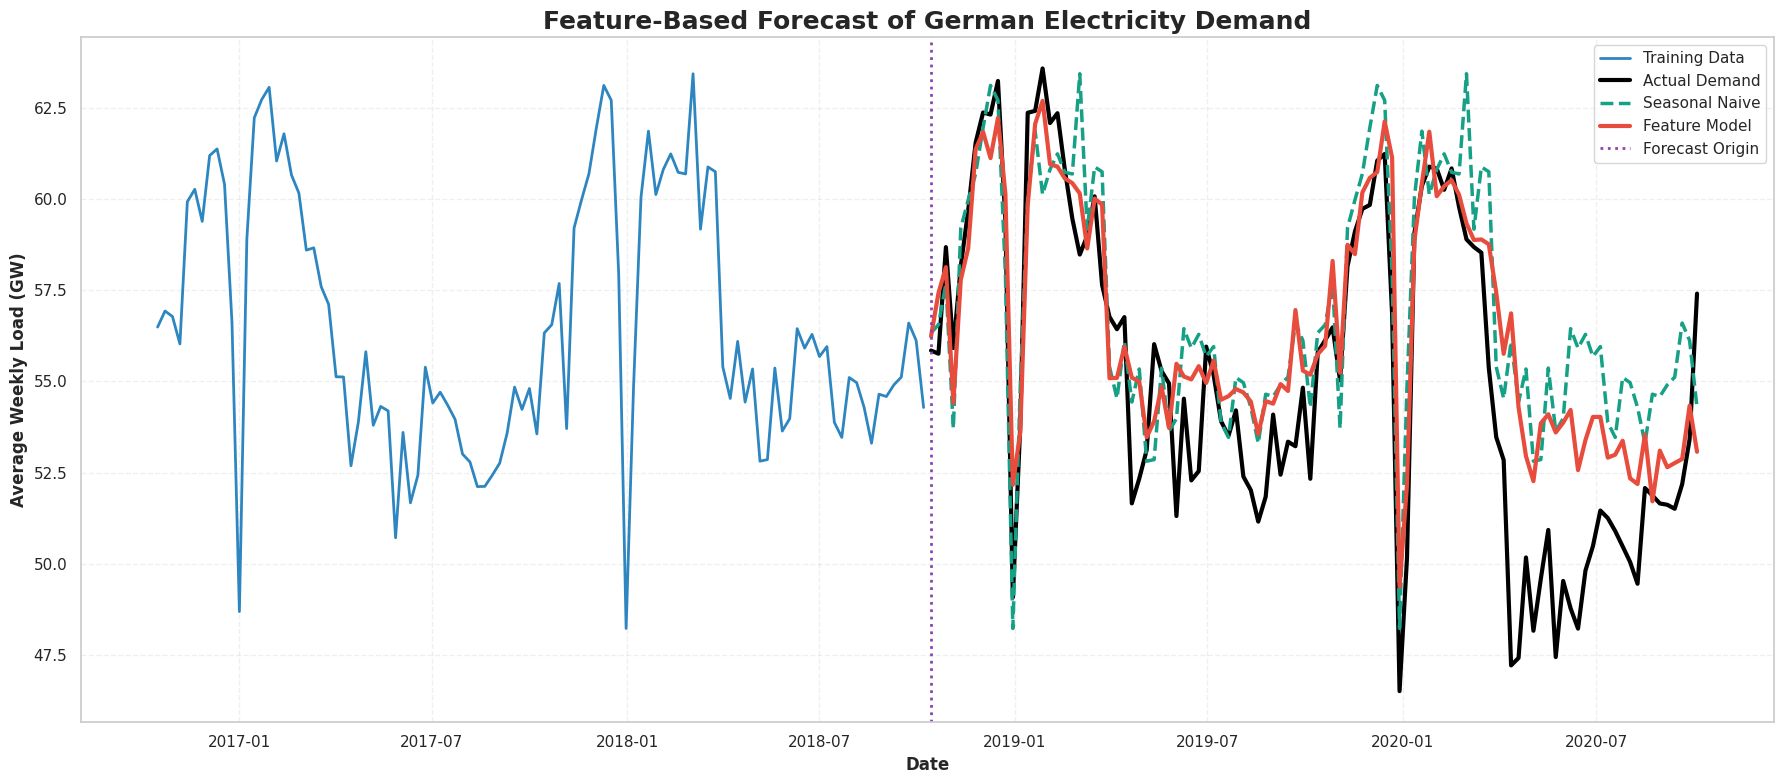

In [ ]:
# ============================================================
# ASSIGNMENT PART 5
# SUB-STEP 5.6: FEATURE MODEL FORECAST VISUALISATION
# ============================================================

plt.figure(figsize=(18,8))

# Training data
plt.plot(
    train.iloc[-104:],
    color="#2E86C1",
    linewidth=2,
    label="Training Data"
)

# Actual observations
plt.plot(
    test,
    color="black",
    linewidth=3,
    label="Actual Demand"
)

# Seasonal Naive benchmark
plt.plot(
    seasonal_naive_forecast,
    color="#16A085",
    linestyle="--",
    linewidth=2.5,
    label="Seasonal Naive"
)

# Feature model
plt.plot(
    feature_forecast,
    color="#E74C3C",
    linewidth=3,
    label="Feature Model"
)

plt.axvline(
    test.index[0],
    color="#8E44AD",
    linestyle=":",
    linewidth=2,
    label="Forecast Origin"
)

plt.title(
    "Feature-Based Forecast of German Electricity Demand",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Weekly Load (GW)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    linestyle="--",
    alpha=0.30
)

plt.legend(
    fontsize=11
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ASSIGNMENT PART 6
# SUB-STEP 6.1: PREPARE HOURLY DATA
# SUB-STEP 6.2: SCALE DATA FOR LSTM
#
# Requirement:
# Prepare hourly electricity demand for LSTM modelling.
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Use hourly electricity demand
hourly_series = hourly_load.copy()

# Two-year test horizon in hours
test_hours = 24 * 365 * 2

train_hourly = hourly_series.iloc[:-test_hours]
test_hourly = hourly_series.iloc[-test_hours:]

print("Training hours:", len(train_hourly))
print("Testing hours :", len(test_hourly))

# Scale data between 0 and 1
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_hourly.values.reshape(-1,1)
)

test_scaled = scaler.transform(
    test_hourly.values.reshape(-1,1)
)

print("\nScaling completed successfully.")

Training hours: 32880
Testing hours : 17520

Scaling completed successfully.


In [ ]:
# ============================================================
# ASSIGNMENT PART 6
# SUB-STEP 6.3: CREATE LSTM SEQUENCES
# SUB-STEP 6.4: BUILD LSTM MODEL
#
# Requirement:
# Build and design an LSTM architecture.
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Sequence length (one week of hourly history)
lookback = 24 * 7

X_train_lstm = []
y_train_lstm = []

for i in range(
    lookback,
    len(train_scaled)
):

    X_train_lstm.append(
        train_scaled[
            i-lookback:i
        ]
    )

    y_train_lstm.append(
        train_scaled[i]
    )

X_train_lstm = np.array(X_train_lstm)
y_train_lstm = np.array(y_train_lstm)

print("LSTM input shape:", X_train_lstm.shape)

# Build LSTM model
lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),

    Dropout(0.2),

    LSTM(
        32
    ),

    Dropout(0.2),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

LSTM input shape: (32712, 168, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# ASSIGNMENT PART 6
# SUB-STEP 6.5: TRAIN AND VALIDATE THE LSTM
# SUB-STEP 6.6: FORECAST THE FINAL TWO YEARS
#
# Requirement:
# Train the LSTM and forecast hourly electricity demand over
# the final two-year test period.
#
# Forecast type:
# Rolling one-step-ahead evaluation. Each prediction uses the
# previous 168 observed hours but never uses the current target.
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping
import time

# ------------------------------------------------------------
# 1. Configure early stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# 2. Train the LSTM model
# ------------------------------------------------------------

start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=128,
    validation_split=0.15,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

training_time = time.time() - start_time

print(f"\nLSTM training completed in {training_time / 60:.2f} minutes.")

# ------------------------------------------------------------
# 3. Combine training and test data for test sequences
# ------------------------------------------------------------

# The final 168 training hours are needed to predict
# the first hour in the test period.
combined_scaled = np.vstack([
    train_scaled,
    test_scaled
])

X_test_lstm = []

# Start at the first test observation.
test_start_position = len(train_scaled)

for i in range(
    test_start_position,
    len(combined_scaled)
):
    X_test_lstm.append(
        combined_scaled[i - lookback:i]
    )

X_test_lstm = np.array(X_test_lstm)

print("Test sequence shape:", X_test_lstm.shape)

# ------------------------------------------------------------
# 4. Predict the final two-year test period
# ------------------------------------------------------------

scaled_predictions = lstm_model.predict(
    X_test_lstm,
    batch_size=256,
    verbose=1
)

# Convert predictions back from 0–1 scale to GW.
lstm_predictions = scaler.inverse_transform(
    scaled_predictions
).flatten()

# Create a time-indexed forecast series.
lstm_forecast = pd.Series(
    lstm_predictions,
    index=test_hourly.index,
    name="LSTM forecast"
)

print("\nLSTM forecast created successfully.")
print(f"Forecasted hours: {len(lstm_forecast):,}")

display(lstm_forecast.head())

Epoch 1/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 42s 176ms/step - loss: 0.0349 - val_loss: 0.0105
Epoch 2/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 39s 179ms/step - loss: 0.0104 - val_loss: 0.0062
Epoch 3/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 41s 186ms/step - loss: 0.0081 - val_loss: 0.0034
Epoch 4/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 40s 185ms/step - loss: 0.0067 - val_loss: 0.0033
Epoch 5/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 39s 178ms/step - loss: 0.0059 - val_loss: 0.0042
Epoch 6/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 40s 182ms/step - loss: 0.0052 - val_loss: 0.0032
Epoch 7/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 39s 181ms/step - loss: 0.0046 - val_loss: 0.0029
Epoch 8/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - loss: 0.0041 - val_loss: 0.0026
Epoch 9/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 39s 180ms/step - loss: 0.0038 - val_loss: 0.0026
Epoch 10/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 39s 181ms/step - loss: 0.0034 - val_loss: 0.0023
Epoch 11/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 39s 180ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 12/20
218/218

,LSTM forecast
date,
2018-10-02 00:00:00,46.784
2018-10-02 01:00:00,46.640
2018-10-02 02:00:00,48.222
2018-10-02 03:00:00,50.938
2018-10-02 04:00:00,55.993


LSTM FORECAST RESULTS
MAE  : 1.482
RMSE : 1.852
MASE : 0.644
Bias : 0.228


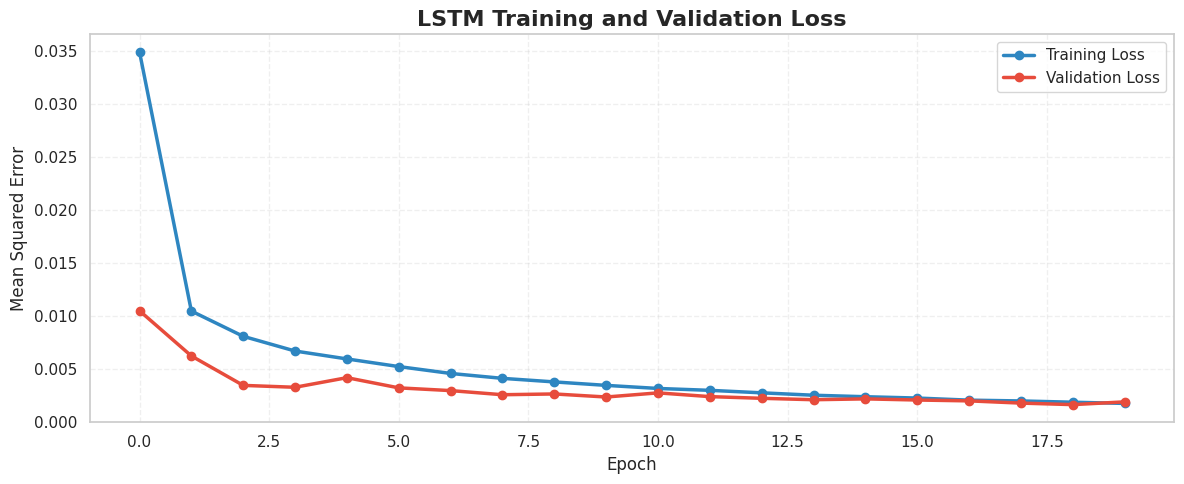

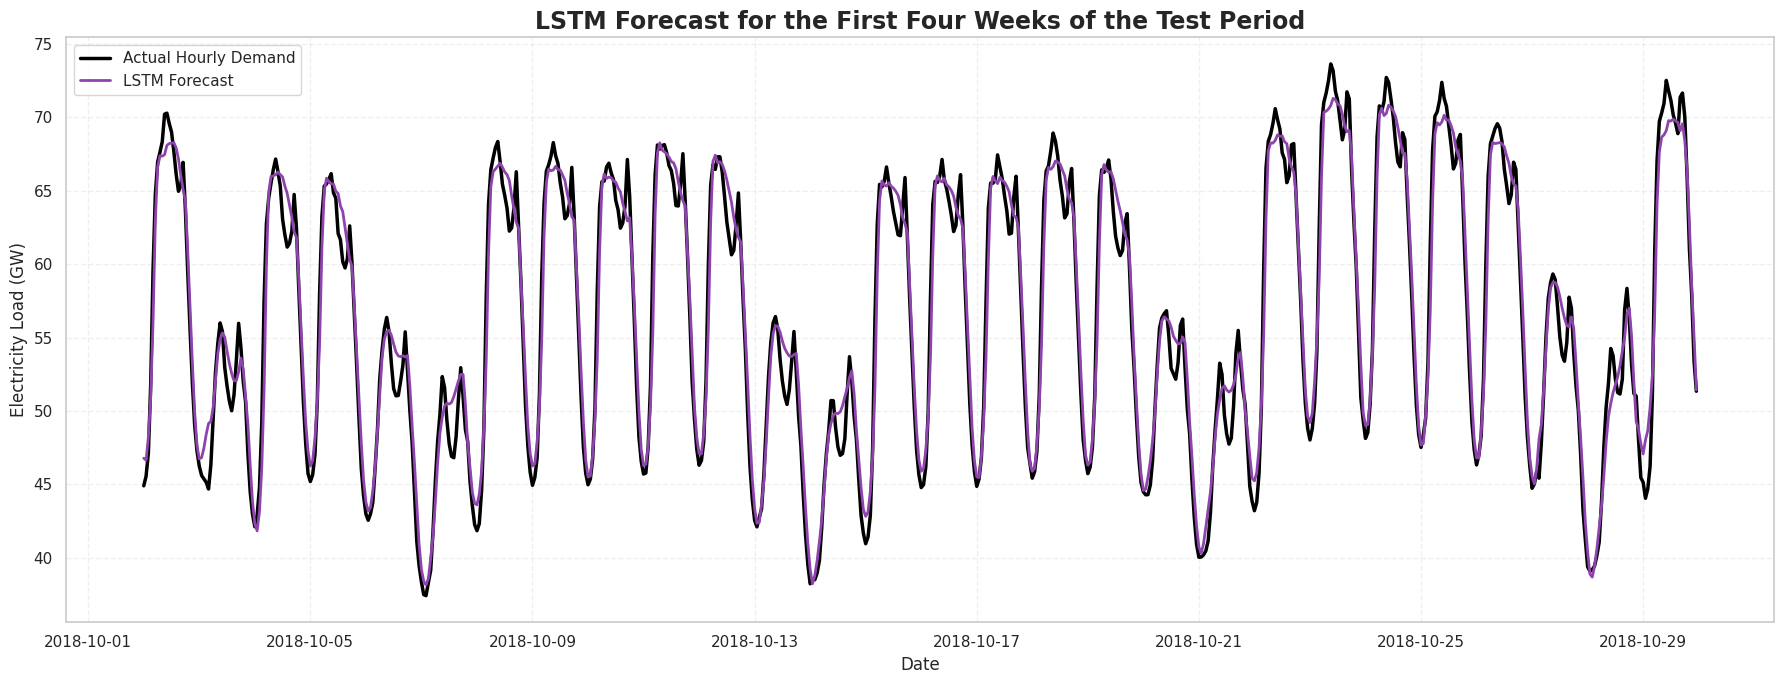

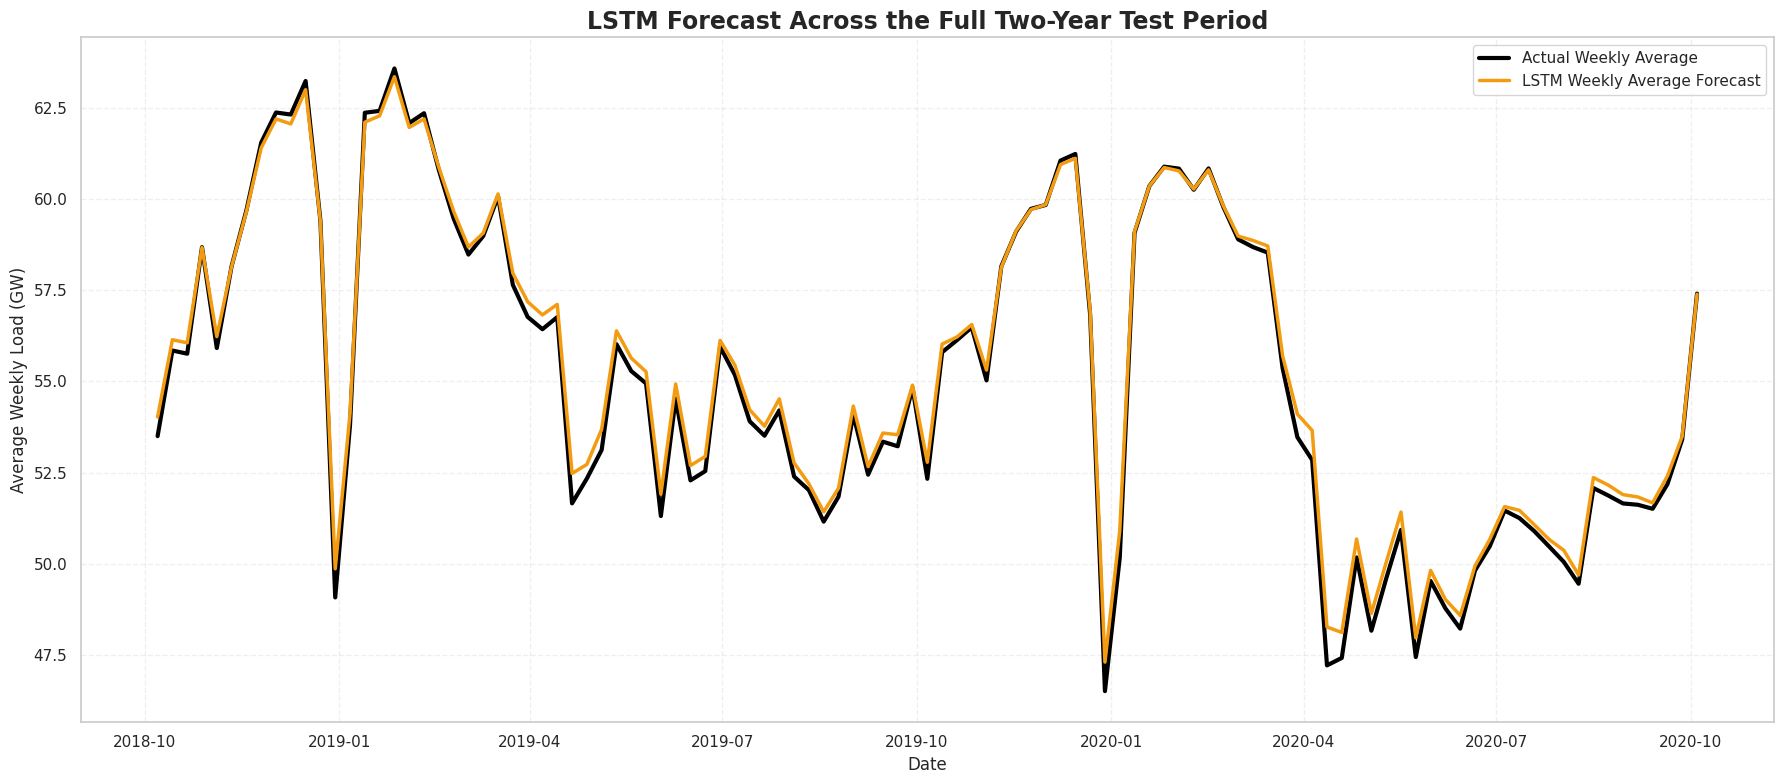

In [ ]:
# ============================================================
# ASSIGNMENT PART 6
# SUB-STEP 6.7: EVALUATE LSTM PERFORMANCE
# SUB-STEP 6.8: PLOT TRAINING AND FORECAST RESULTS
#
# Requirements satisfied:
# ✓ Compute MAE, RMSE, MASE and Bias
# ✓ Plot training and validation loss
# ✓ Plot actual vs forecast hourly demand
# ✓ Compare LSTM against Seasonal Naive benchmark
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# 1. Calculate LSTM evaluation metrics
# ------------------------------------------------------------

lstm_mae = mean_absolute_error(
    test_hourly,
    lstm_forecast
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        test_hourly,
        lstm_forecast
    )
)

# Hourly seasonal MASE denominator:
# compare each training hour with the same hour one week earlier.
hourly_seasonality = 24 * 7

hourly_naive_errors = np.abs(
    train_hourly.iloc[hourly_seasonality:].values
    - train_hourly.iloc[:-hourly_seasonality].values
)

lstm_mase = np.mean(
    np.abs(
        test_hourly.values
        - lstm_forecast.values
    )
) / hourly_naive_errors.mean()

lstm_bias = np.mean(
    lstm_forecast.values
    - test_hourly.values
)

print("=" * 60)
print("LSTM FORECAST RESULTS")
print("=" * 60)

print(f"MAE  : {lstm_mae:.3f}")
print(f"RMSE : {lstm_rmse:.3f}")
print(f"MASE : {lstm_mase:.3f}")
print(f"Bias : {lstm_bias:.3f}")

# ------------------------------------------------------------
# 2. Plot training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    lstm_history.history["loss"],
    color="#2E86C1",
    linewidth=2.5,
    marker="o",
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    color="#E74C3C",
    linewidth=2.5,
    marker="o",
    label="Validation Loss"
)

plt.title(
    "LSTM Training and Validation Loss",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Plot a representative 4-week test window
# ------------------------------------------------------------

plot_hours = 24 * 28

plt.figure(figsize=(18, 7))

plt.plot(
    test_hourly.iloc[:plot_hours].index,
    test_hourly.iloc[:plot_hours].values,
    color="black",
    linewidth=2.5,
    label="Actual Hourly Demand"
)

plt.plot(
    lstm_forecast.iloc[:plot_hours].index,
    lstm_forecast.iloc[:plot_hours].values,
    color="#8E44AD",
    linewidth=2,
    label="LSTM Forecast"
)

plt.title(
    "LSTM Forecast for the First Four Weeks of the Test Period",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Electricity Load (GW)")
plt.grid(linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Plot full test-period weekly averages
# ------------------------------------------------------------

actual_weekly_lstm = test_hourly.resample("W-SUN").mean()

forecast_weekly_lstm = lstm_forecast.resample("W-SUN").mean()

plt.figure(figsize=(18, 8))

plt.plot(
    actual_weekly_lstm.index,
    actual_weekly_lstm.values,
    color="black",
    linewidth=3,
    label="Actual Weekly Average"
)

plt.plot(
    forecast_weekly_lstm.index,
    forecast_weekly_lstm.values,
    color="#F39C12",
    linewidth=2.5,
    label="LSTM Weekly Average Forecast"
)

plt.title(
    "LSTM Forecast Across the Full Two-Year Test Period",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Weekly Load (GW)")
plt.grid(linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ASSIGNMENT PART 4
# SUB-STEP 4.8: CREATE GERMAN HOLIDAY FEATURES
# SUB-STEP 4.9: FIT SARIMAX WITH TEMPERATURE AND HOLIDAYS
#
# Requirement:
# Evaluate whether temperature and holiday covariates
# improve weekly forecast accuracy.
# ============================================================

!pip install holidays -q

import holidays
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ------------------------------------------------------------
# 1. Create German public-holiday calendar
# ------------------------------------------------------------

german_holidays = holidays.Germany(
    years=range(2015, 2021)
)

# Create complete daily calendar.
daily_calendar = pd.DataFrame(
    index=pd.date_range(
        start="2015-01-01",
        end="2020-09-30",
        freq="D"
    )
)

# Mark public holidays.
daily_calendar["is_holiday"] = [
    int(date.date() in german_holidays)
    for date in daily_calendar.index
]

# Count holidays within each week.
holiday_weekly = (
    daily_calendar["is_holiday"]
    .resample("W-SUN")
    .sum()
    .reindex(weekly_load.index)
    .fillna(0)
    .to_frame("holiday_days")
)

# Indicator showing whether a week contains a holiday.
holiday_weekly["has_holiday"] = (
    holiday_weekly["holiday_days"] > 0
).astype(int)

print("Total German holiday days:", int(holiday_weekly["holiday_days"].sum()))
print("Holiday weeks:", int(holiday_weekly["has_holiday"].sum()))

# ------------------------------------------------------------
# 2. Combine temperature and holiday covariates
# ------------------------------------------------------------

exog_temp_holiday = pd.concat(
    [
        temp_weekly[
            [
                "temp_mean",
                "heating_degree_days",
                "cooling_degree_days"
            ]
        ],
        holiday_weekly
    ],
    axis=1
)

# Align with weekly electricity dates.
exog_temp_holiday = (
    exog_temp_holiday
    .reindex(weekly_load.index)
    .interpolate(method="time", limit_direction="both")
    .fillna(0)
)

X_train_temp_holiday = exog_temp_holiday.loc[train.index]
X_test_temp_holiday = exog_temp_holiday.loc[test.index]

# ------------------------------------------------------------
# 3. Fit SARIMAX with temperature and holidays
# ------------------------------------------------------------

sarimax_holiday_model = SARIMAX(
    train,
    exog=X_train_temp_holiday,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_holiday_fit = sarimax_holiday_model.fit(
    disp=False,
    maxiter=100
)

print("\nSARIMAX with temperature and holidays fitted.")
print(f"AIC: {sarimax_holiday_fit.aic:.3f}")

Total German holiday days: 52
Holiday weeks: 47

SARIMAX with temperature and holidays fitted.
AIC: 250.106


In [ ]:
# ============================================================
# ASSIGNMENT PART 4
# SUB-STEP 4.10: FORECAST WITH TEMPERATURE AND HOLIDAYS
# SUB-STEP 4.11: COMPARE SARIMAX COVARIATES
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Produce conditional forecast.
holiday_forecast_object = sarimax_holiday_fit.get_forecast(
    steps=len(test),
    exog=X_test_temp_holiday
)

sarimax_holiday_forecast = (
    holiday_forecast_object.predicted_mean.copy()
)

sarimax_holiday_forecast.index = test.index

sarimax_holiday_confidence = (
    holiday_forecast_object.conf_int(alpha=0.05)
)

sarimax_holiday_confidence.index = test.index

# Calculate metrics.
holiday_mae = mean_absolute_error(
    test,
    sarimax_holiday_forecast
)

holiday_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarimax_holiday_forecast
    )
)

holiday_mase = np.mean(
    np.abs(
        test.values -
        sarimax_holiday_forecast.values
    )
) / mase_scale

holiday_bias = np.mean(
    sarimax_holiday_forecast.values -
    test.values
)

covariate_comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "SARIMAX Temperature",
        "SARIMAX Temperature + Holidays"
    ],
    "MAE": [
        sarima_mae,
        sarimax_mae,
        holiday_mae
    ],
    "RMSE": [
        sarima_rmse,
        sarimax_rmse,
        holiday_rmse
    ],
    "MASE": [
        sarima_mase,
        sarimax_mase,
        holiday_mase
    ],
    "Bias": [
        sarima_bias,
        sarimax_bias,
        holiday_bias
    ]
}).sort_values("RMSE").reset_index(drop=True)

print("=" * 65)
print("TEMPERATURE AND HOLIDAY COVARIATE COMPARISON")
print("=" * 65)

display(covariate_comparison.round(3))

print(
    "\nThese are conditional forecasts because observed "
    "test-period temperature was provided. Holiday dates are "
    "known in advance, but future observed temperature is not."
)

TEMPERATURE AND HOLIDAY COVARIATE COMPARISON


,Model,MAE,RMSE,MASE,Bias
0,SARIMAX Temperature + Holidays,2.762,3.510,2.064,2.666
1,SARIMAX Temperature,2.819,3.580,2.106,2.594
2,SARIMA,3.030,3.736,2.264,2.806



These are conditional forecasts because observed test-period temperature was provided. Holiday dates are known in advance, but future observed temperature is not.


In [ ]:
# ============================================================
# ASSIGNMENT PART 7
# SUB-STEP 7.1: COMBINE ALL MODEL RESULTS
# SUB-STEP 7.2: COMPARE MODELS WITH SEASONAL NAIVE
#
# Requirements:
# ✓ Include a table of evaluation metrics
# ✓ Compare every model with Seasonal Naive
# ✓ Calculate percentage improvement in RMSE
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# Convert hourly LSTM predictions to weekly averages
# ------------------------------------------------------------

lstm_actual_weekly = test_hourly.resample("W-SUN").mean()
lstm_forecast_weekly = lstm_forecast.resample("W-SUN").mean()

# Keep dates common to both series
common_lstm_dates = (
    lstm_actual_weekly.index
    .intersection(lstm_forecast_weekly.index)
)

lstm_actual_weekly = lstm_actual_weekly.loc[common_lstm_dates]
lstm_forecast_weekly = lstm_forecast_weekly.loc[common_lstm_dates]

# Calculate weekly LSTM metrics
lstm_weekly_mae = mean_absolute_error(
    lstm_actual_weekly,
    lstm_forecast_weekly
)

lstm_weekly_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual_weekly,
        lstm_forecast_weekly
    )
)

lstm_weekly_mase = np.mean(
    np.abs(
        lstm_actual_weekly.values -
        lstm_forecast_weekly.values
    )
) / mase_scale

lstm_weekly_bias = np.mean(
    lstm_forecast_weekly.values -
    lstm_actual_weekly.values
)

# ------------------------------------------------------------
# Create final model comparison table
# ------------------------------------------------------------

final_results = pd.DataFrame({
    "Model": [
        "Mean",
        "Naive",
        "Seasonal Naive",
        "Drift",
        "SARIMA",
        "SARIMAX Temperature",
        "SARIMAX Temperature + Holidays",
        "Feature Model",
        "LSTM"
    ],

    "MAE": [
        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Mean", "MAE"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Naive", "MAE"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Seasonal Naive", "MAE"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Drift", "MAE"
        ].iloc[0],

        sarima_mae,
        sarimax_mae,
        holiday_mae,
        feature_mae,
        lstm_weekly_mae
    ],

    "RMSE": [
        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Mean", "RMSE"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Naive", "RMSE"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Seasonal Naive", "RMSE"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Drift", "RMSE"
        ].iloc[0],

        sarima_rmse,
        sarimax_rmse,
        holiday_rmse,
        feature_rmse,
        lstm_weekly_rmse
    ],

    "MASE": [
        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Mean", "MASE"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Naive", "MASE"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Seasonal Naive", "MASE"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Drift", "MASE"
        ].iloc[0],

        sarima_mase,
        sarimax_mase,
        holiday_mase,
        feature_mase,
        lstm_weekly_mase
    ],

    "Bias": [
        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Mean", "Bias"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Naive", "Bias"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Seasonal Naive", "Bias"
        ].iloc[0],

        benchmark_results_df.loc[
            benchmark_results_df["Model"] == "Drift", "Bias"
        ].iloc[0],

        sarima_bias,
        sarimax_bias,
        holiday_bias,
        feature_bias,
        lstm_weekly_bias
    ]
})

# Seasonal Naive is the required benchmark
seasonal_naive_rmse = final_results.loc[
    final_results["Model"] == "Seasonal Naive",
    "RMSE"
].iloc[0]

# Positive percentage means improvement over Seasonal Naive
final_results["RMSE Improvement vs Seasonal Naive (%)"] = (
    (
        seasonal_naive_rmse - final_results["RMSE"]
    )
    / seasonal_naive_rmse
) * 100

# Rank models using RMSE
final_results = (
    final_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

final_results.insert(
    0,
    "Rank",
    np.arange(1, len(final_results) + 1)
)

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(
    final_results.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "MASE": "{:.3f}",
        "Bias": "{:.3f}",
        "RMSE Improvement vs Seasonal Naive (%)": "{:.2f}%"
    })
)

print(
    "\nBest model based on RMSE:",
    final_results.iloc[0]["Model"]
)

FINAL MODEL COMPARISON


,Rank,Model,MAE,RMSE,MASE,Bias,RMSE Improvement vs Seasonal Naive (%)
0,1,LSTM,0.269,0.340,0.201,0.227,88.69%
1,2,Feature Model,1.792,2.444,1.339,1.232,18.71%
2,3,Seasonal Naive,2.319,3.007,1.732,1.732,0.00%
3,4,SARIMAX Temperature + Holidays,2.762,3.510,2.064,2.666,-16.75%
4,5,SARIMAX Temperature,2.819,3.580,2.106,2.594,-19.05%
5,6,SARIMA,3.030,3.736,2.264,2.806,-24.27%
6,7,Mean,3.789,4.397,2.831,0.481,-46.25%
7,8,Naive,3.783,4.459,2.827,-0.882,-48.30%
8,9,Drift,4.340,5.118,3.243,1.007,-70.21%



Best model based on RMSE: LSTM
